# Rampa in T del GaSb

Per la prima temperatura  $T_1=78.68$  K si raccoglie lo spettro a 6 diverse intensità [0e5, 1, 2e5, 5, 10, 25]

In [222]:
arr_filtro = ['0e5', '1', '2e5', '5', '10', '25'] # + 'pc'

Per ciascuna delle successive 20 temperature, si raccoglie lo spettro con filtro 0e5.

In [223]:
arr_T = ['78e68', '90', '100', '110', '120', '130', '140', '150', '160', '170', '180',
      '190', '200', '210', '220', '230', '240', '250', '260', '280', '300'] # + 'K'

## Importazioni

In [224]:
from qp2_subroutines import *
import os

In [225]:
os.getcwd() 

'/Users/zosojack/lab-ss/QP2'

## Preliminari

#### Per la conversione

In [226]:
# conversione lambda (nm) in E (eV)
def lambda_to_E (wavelength: float):
    h_in_ev = 4.1357e-15
    c_luce  = 299792458
    
    if isinstance(wavelength, (int, float)):  # Caso scalare
        return h_in_ev * c_luce / (wavelength * 1e-09) if wavelength != 0 else 0

    elif isinstance(wavelength, np.ndarray):  # Caso np.array
        return h_in_ev * c_luce / (wavelength * 1e-09)

    elif isinstance(wavelength, list):  # Caso lista
        return np.array([h_in_ev * c_luce / (wv * 1e-09) for wv in wavelength])

    else:
        raise TypeError("Input non supportato. Usa float, list o np.ndarray.")


# propagazione errore lambda (nm) in E (eV)
def err_lambda_to_E(wavelength, err_wavelength):
    h_in_ev = 4.1357e-15
    c_luce = 299792458

    wavelength = np.asarray(wavelength)
    err_wavelength = np.asarray(err_wavelength)

    return np.where(wavelength != 0, h_in_ev * c_luce * err_wavelength / (wavelength**2 * 1e-09), 0)

#### Per la costruzione dei nomi dei file

In [227]:
def build_name_GaSb (T: str = None, filtro: str = None):
    # t_acq == 0e1
    # n_acq == 4
    # grating == 35lmm
    # ecc=None
    fen='fen1e1'
    
    if T is None:
        T = '78e68'
    if filtro is None:
        filtro = '0e5'
    
    cartella = 'data/rampa_T_GaSb/'
    name = 'Giak_' + '0e1_4_35lmm_' + T + 'K_' + filtro + 'pc_' + fen + '.asc'
    
    return cartella+name

Per il fit: opto per la somma di N gaussiane.

Il vettore params viene definito come una list di N triple (a, mu, sigma), una per ciascuna gaussiana. Successivamente deve essere 'appiattito' con .flatten() per renderlo un array unidimensionale, trattabile da curve_fit().

In [228]:
def N_gaussiane (x, *params):
    # Inizializzo il risultato
    y = np.zeros_like(x)
    # Sommo una gaussiana per ciascuna entrata della list
    for i in range(0, len(params), 3):  # Scandisco i parametri a gruppi di 3
        A, mu, sigma = params[i], params[i+1], params[i+2]
        y += gaussiana(x, A, mu, sigma)
        
    return y

Servirà dopo per i colori nei grafici.

In [229]:
col = ['red', 'green', 'magenta', 'purple', 'peru', 'cyan', 
       'olive', 'goldenrod', 'black', 'sienna', 'steelblue', 'crimson']

Fare caso al fatto che fit_N_gaussiane prende in argomento il numero di acquisizioni! Il motivo è spiegato bene nella docstring. In breve: serve a correggere con un senso l'errore poissoniano!

---

---

# Analisi

In una prima fase abbiamo anche verificato che 0e1 fosse il tempo di acquisizione ottimale, si potrebbe inserire nell'analisi.

## GaSb: T=79K su INTENSITÀ

#### Contenitore per i dati

In [230]:
# dictionary GaSb
# le keys saranno i filtri
# ciascuna key conterrà le due colonne del file:
# GaSb[filtro][0] - colonna 0 del file (lunghezze d'onda)
# GaSb[filtro][1] - colonna 1 del file (counts)

GaSb_flt = {}

#### Lettura file

In [231]:
for filtro in arr_filtro:
    
    # Costruisco nome file
    name = build_name_GaSb (filtro=filtro)
    # Estraggo i dati 
    waveln, counts = leggi_file_asc (name)
    # Pulisco i counts da valori insensati 
    counts = clean_counts (counts, peak=False)
    # Raccolgo
    GaSb_flt[filtro] = (waveln, counts)

#### Plot su intensità + FIT somma Gaussiane

- - - - - - - - - - - - - - - - - - - - - - - - - -
prevent_overfitting ha RIMOSSO 0 picchi
- - - - - - - - - - - - - - - - - - - - - - - - - -


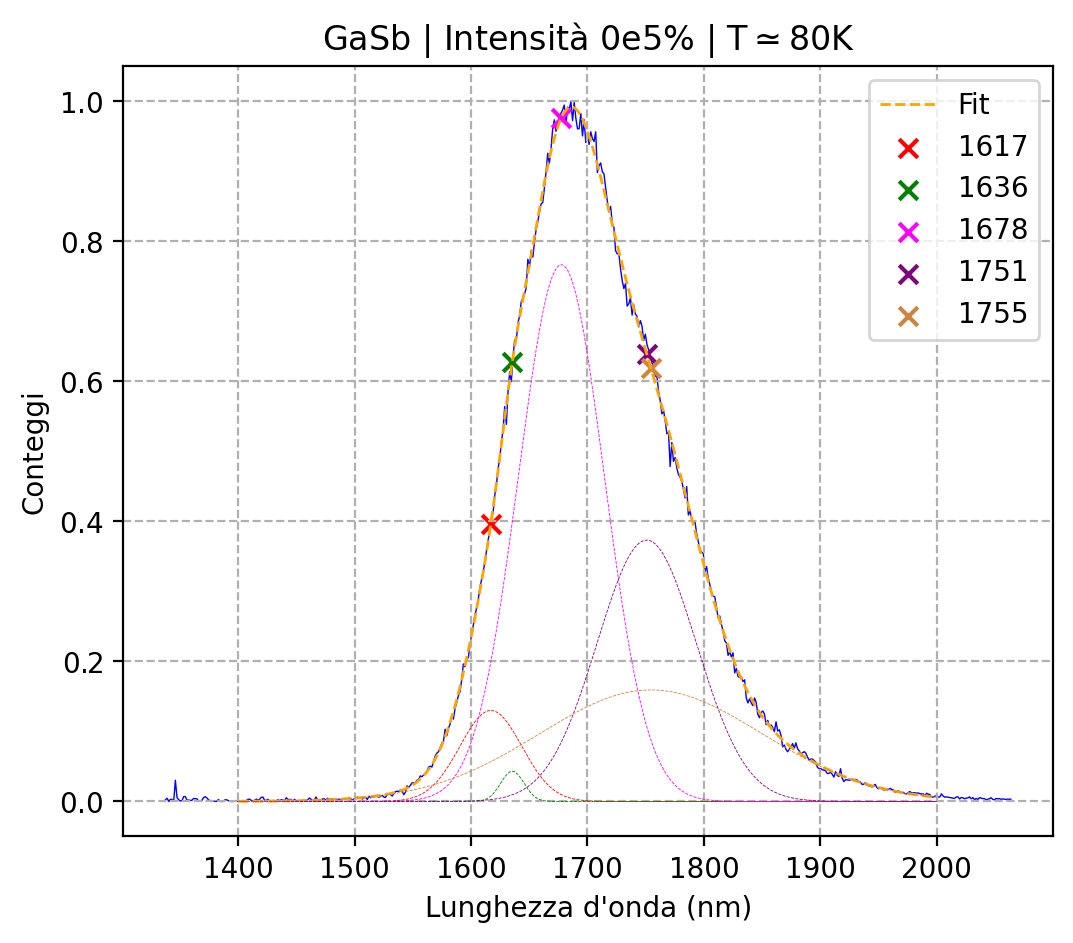

• Gaussiana  1
 - A = 0.043153064915532384
 - mu = 1635.528210294451
 - sigma = 10.000000000000002
• Gaussiana  2
 - A = 0.7667444894958855
 - mu = 1677.641205421992
 - sigma = 36.92217495830252
• Gaussiana  3
 - A = 0.15929817694893797
 - mu = 1754.5127663347803
 - sigma = 95.75307582881625
• Gaussiana  4
 - A = 0.12994259779348083
 - mu = 1617.0664692658354
 - sigma = 26.557864017087475
• Gaussiana  5
 - A = 0.3733230161683606
 - mu = 1750.891413544044
 - sigma = 42.58445288191746
 - chi2rid = inf
- - - - - - - - - - - - - - - - - - - - - - - - - -
prevent_overfitting ha RIMOSSO 0 picchi
- - - - - - - - - - - - - - - - - - - - - - - - - -


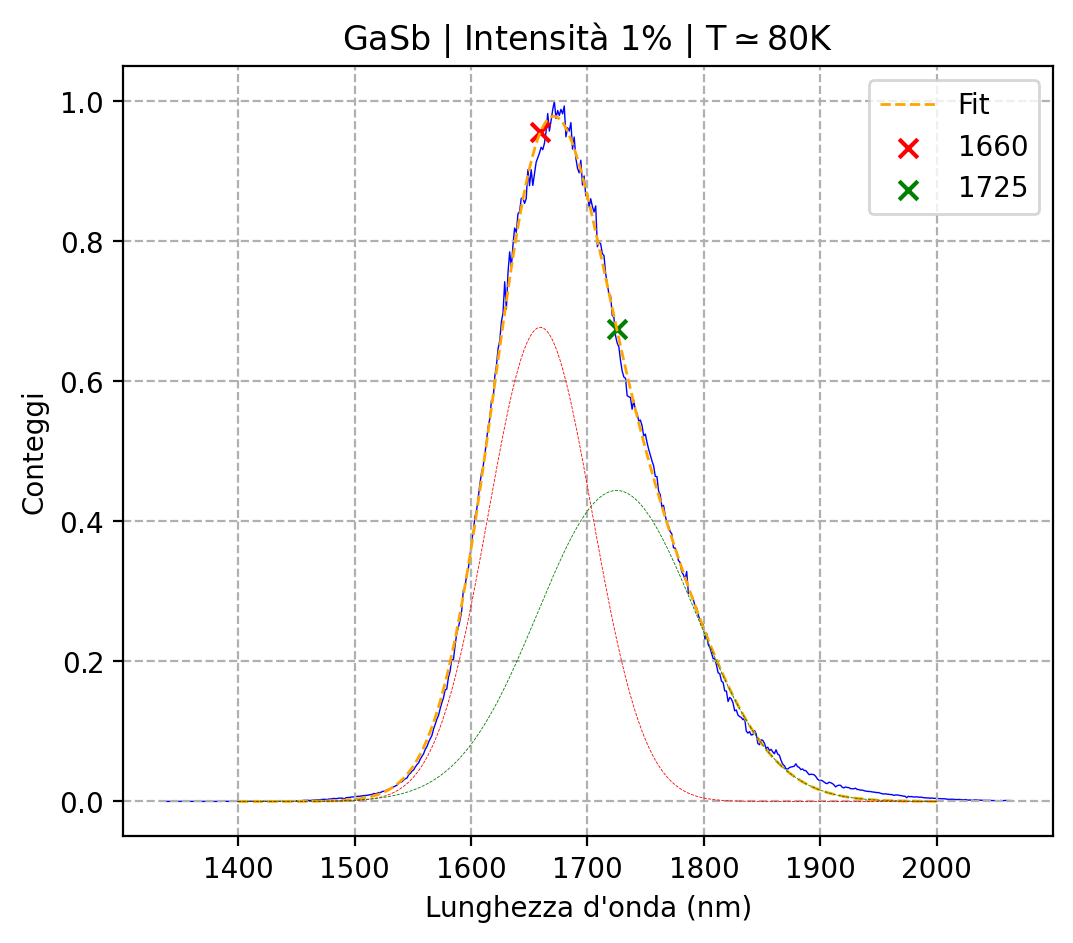

• Gaussiana  1
 - A = 0.6772669861597449
 - mu = 1659.5722420844056
 - sigma = 44.69754987553825
• Gaussiana  2
 - A = 0.4442779896867205
 - mu = 1725.1088633904383
 - sigma = 67.88512027710705
 - chi2rid = 0.4088285792136219
- - - - - - - - - - - - - - - - - - - - - - - - - -
prevent_overfitting ha RIMOSSO 0 picchi
- - - - - - - - - - - - - - - - - - - - - - - - - -


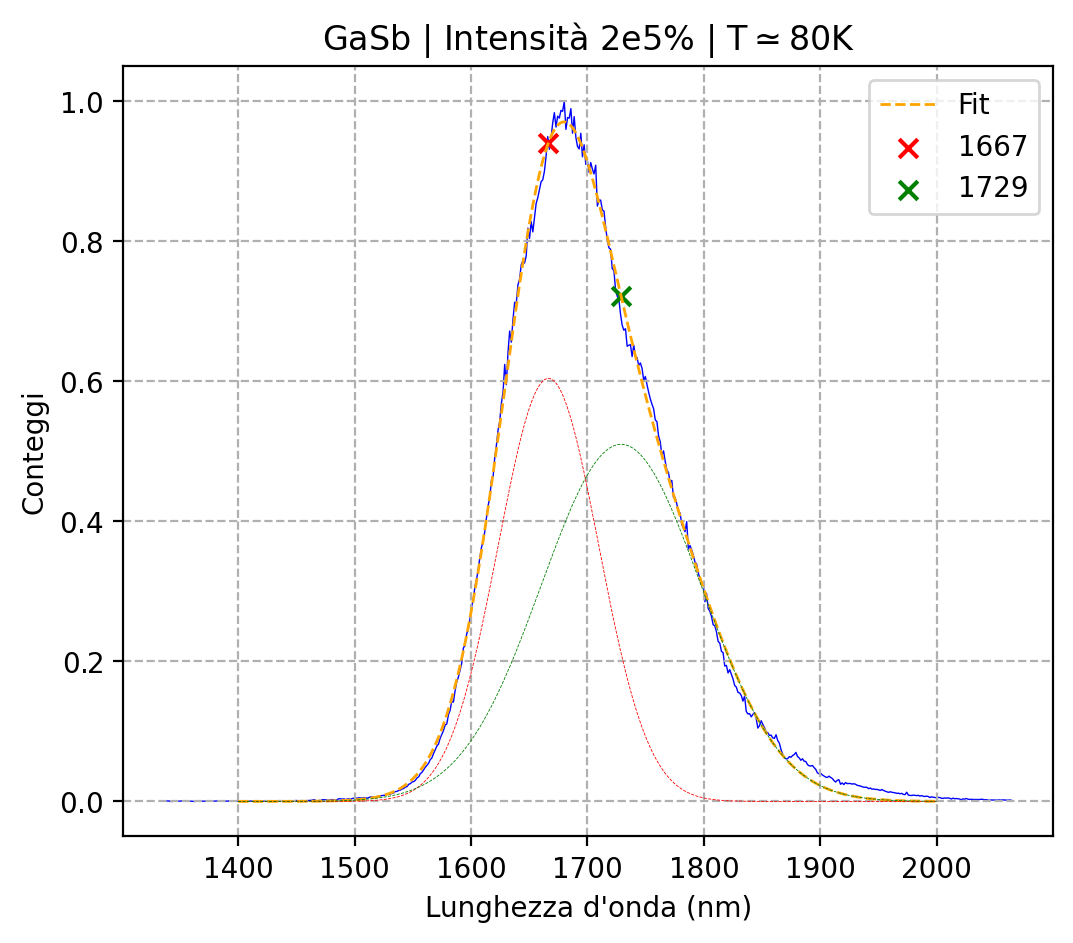

• Gaussiana  1
 - A = 0.6043364729989498
 - mu = 1666.553958260811
 - sigma = 43.04887242500149
• Gaussiana  2
 - A = 0.5101901598645242
 - mu = 1728.9424960408855
 - sigma = 68.50365812058516
 - chi2rid = 0.4697475919032373
- - - - - - - - - - - - - - - - - - - - - - - - - -
prevent_overfitting ha RIMOSSO 0 picchi
- - - - - - - - - - - - - - - - - - - - - - - - - -


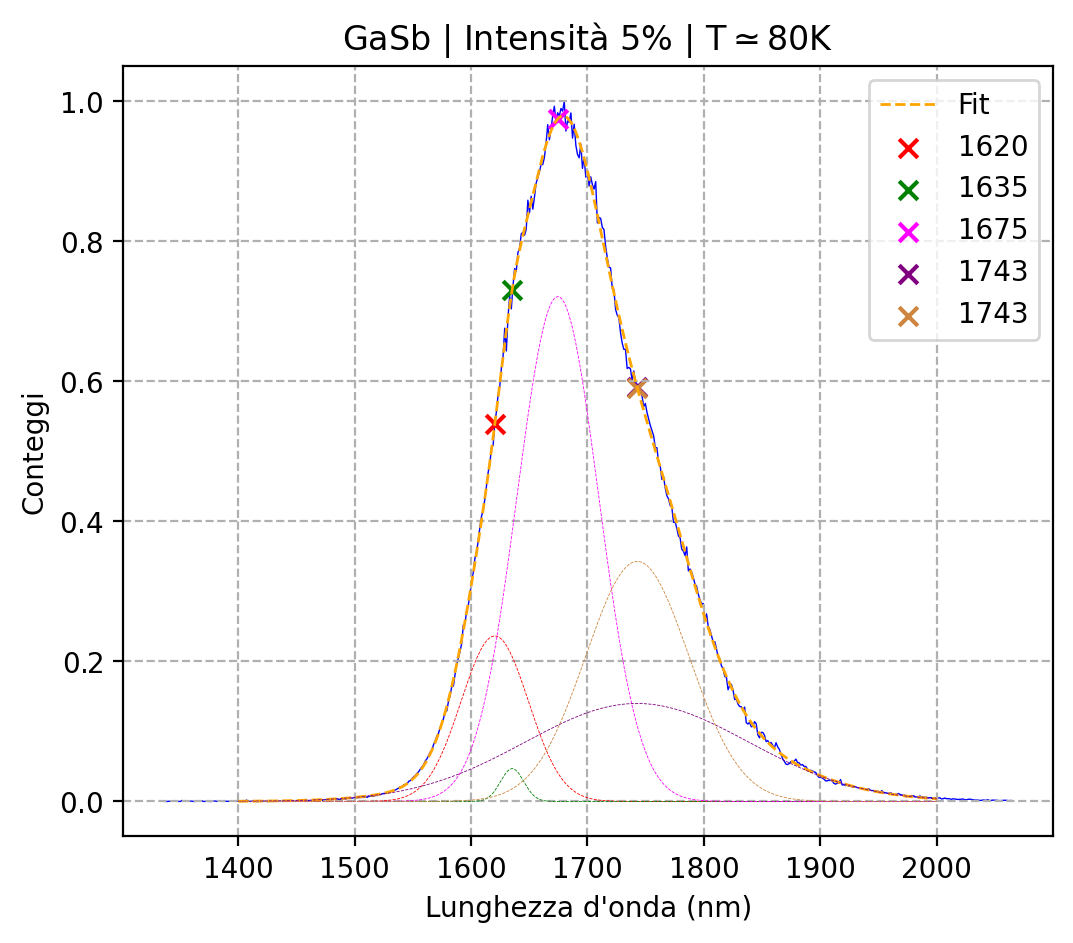

• Gaussiana  1
 - A = 0.342876147675745
 - mu = 1742.839312292491
 - sigma = 44.25356608612629
• Gaussiana  2
 - A = 0.13996149132857416
 - mu = 1742.5259845785913
 - sigma = 95.85550195269788
• Gaussiana  3
 - A = 0.04683516931235057
 - mu = 1635.3664902011699
 - sigma = 10.000000000000002
• Gaussiana  4
 - A = 0.2364003871725772
 - mu = 1620.4498493409471
 - sigma = 28.8632852049481
• Gaussiana  5
 - A = 0.7211811076402496
 - mu = 1674.5986375992436
 - sigma = 34.97944677596938
 - chi2rid = inf
- - - - - - - - - - - - - - - - - - - - - - - - - -
prevent_overfitting ha RIMOSSO 0 picchi
- - - - - - - - - - - - - - - - - - - - - - - - - -


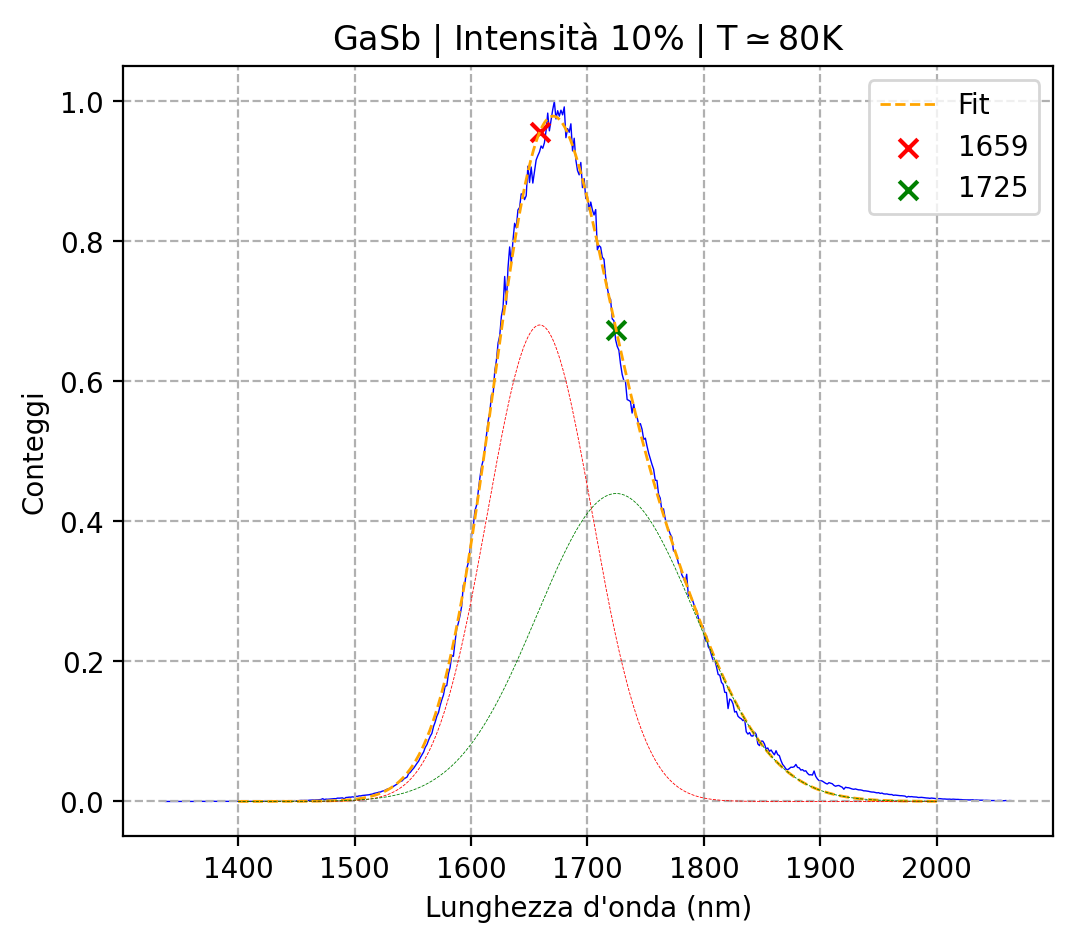

• Gaussiana  1
 - A = 0.6806832714034413
 - mu = 1659.089491244476
 - sigma = 44.8452598520924
• Gaussiana  2
 - A = 0.43993031023872436
 - mu = 1724.7362713342534
 - sigma = 67.9784663311321
 - chi2rid = 0.40937636040246844
- - - - - - - - - - - - - - - - - - - - - - - - - -
prevent_overfitting ha RIMOSSO 0 picchi
- - - - - - - - - - - - - - - - - - - - - - - - - -


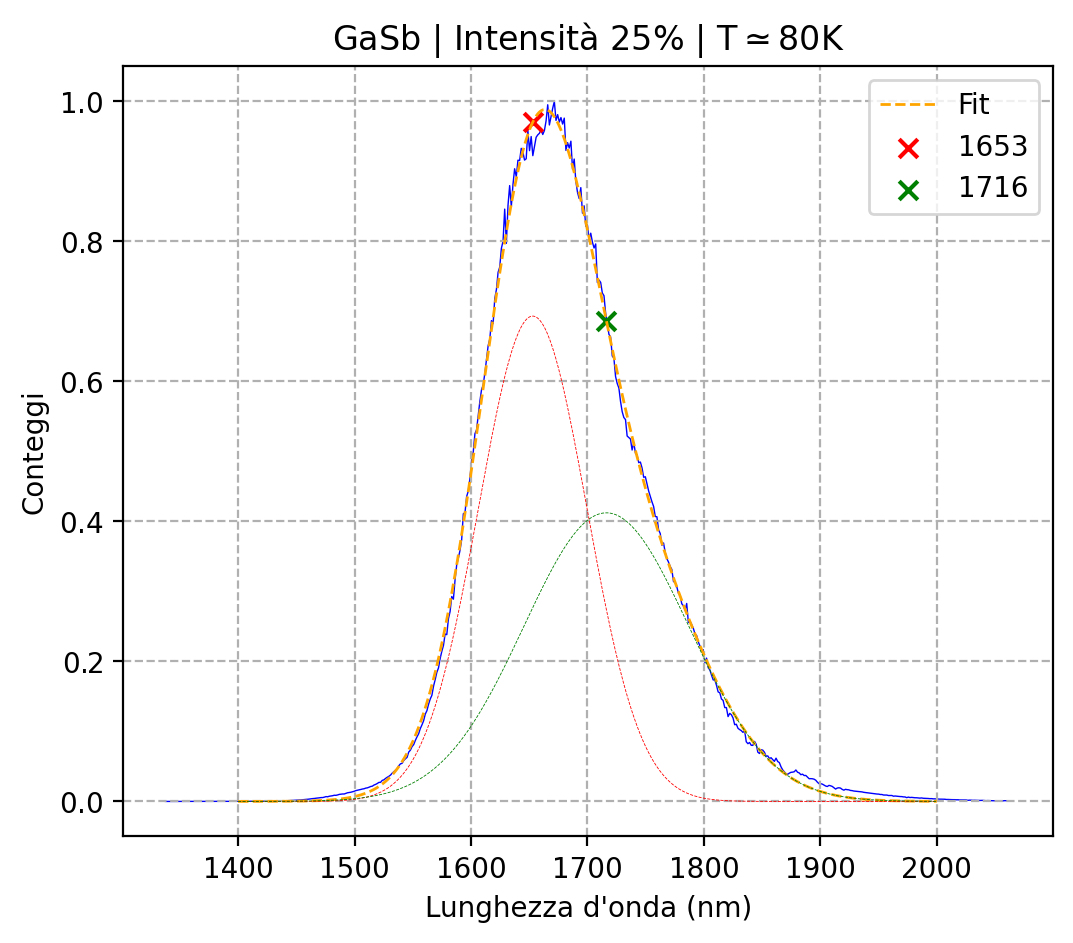

• Gaussiana  1
 - A = 0.41231572591759647
 - mu = 1716.247942029136
 - sigma = 70.87187801059194
• Gaussiana  2
 - A = 0.693382857824201
 - mu = 1652.9980303660623
 - sigma = 46.44480340147485
 - chi2rid = 0.3698325684029617


In [232]:
for filtro in arr_filtro:
    
    waveln = GaSb_flt[filtro][0]
    counts = GaSb_flt[filtro][1]
    
    # normalizzo i counts
    maximum = np.max(counts)
    counts = counts / maximum

    # Plot
    plt.figure(figsize=(6,5), dpi=200)
    plt.plot(waveln, counts, linestyle='-', color='b', linewidth=0.5, zorder=1)
    
    ## FIT ##
    
    # isolo regione 1400 < x < 2000
    mask = (waveln > 1400) & (waveln < 2000)
    x_fit = waveln[mask]
    y_fit = counts[mask]
    
    # impostazione parametri: ogni entrata è una tripla (a, mu, sigma)
    params = [
        (1, 1700, 50)
    ]
    
    # Set dei bounds
    low = [0, 1500, 10] * len(params)  # Es: A >= 0, mu >= 1500, sigma >= 10
    upp = [1, 1900, 200] * len(params)  # Limiti superiori
    
    popt, pcov, chi2_reduced = fit_N_gaussiane(x_fit, y_fit, params, bounds=(low,upp))
        
    ## PLOT CURVA FIT ##
    x_plot = np.linspace(1400, 2000, 500)
    y_plot = N_gaussiane(x_plot, *popt)
    plt.plot(x_plot, y_plot, linestyle='--', color='orange', label=f"Fit", linewidth=1, zorder=2)
        
    # estraggo da popt i parametri ottimizzati
    valori = [] # inizializzo
    for i in range(0, round(len(popt)/3)):
        valori.append((popt[3*i], popt[3*i+1], popt[3*i+2]))
    # li imposto per la prossima gaussiana
    params = valori
    
    # organizzo i picchi in ordine crescente
    valori = sorted(valori, key=lambda p: float(p[1]))
    n_picchi = len(valori)
    
    # plotto i picchi individuati dal fit
    for i in range(n_picchi): 
        x_picco = valori[i][1]
        y_picco = N_gaussiane(x_picco, *popt)
        plt.scatter(x_picco, y_picco, 
                    color=col[i], marker='x',
                    label=str(round(x_picco)), # stampa nel plot le lambda dei picchi
                    s=45, #alpha=0-1 per opacità
                    #zorder=3
                    )
    
    # plotto singolarmente le gaussiane
    for i in range(n_picchi):
        y_gauss = gaussiana(x_plot, *valori[i])
        plt.plot(x_plot, y_gauss, linestyle='--', color=col[i], linewidth=0.3, zorder=2)
    
    ## OPZIONI GRAFICHE ##
    plt.title(r'GaSb | Intensità ' + filtro + '% | T$\simeq80$K')
    plt.xlabel("Lunghezza d'onda (nm)")
    plt.ylabel("Conteggi")
    plt.ticklabel_format(axis='y',style='scientific', useMathText=True, scilimits=(0,0) )
    plt.legend()
    plt.grid(linestyle='--')
    #plt.tight_layout()
    plt.show()
    
    
    ## PRINT RISULTATI FIT ##
    for i in range(0, round(len(popt)/3)):
        print('• Gaussiana ', i+1)
        print(' - A =', popt[3*i])
        print(' - mu =', popt[3*i+1])
        print(' - sigma =', popt[3*i+2])
    print(' - chi2rid =', chi2_reduced)

---

---

## GaSb: filtro=0e5pc su TEMPERATURA

#### Contenitore per i dati

In [233]:
# dictionary GaSb
# le keys saranno i filtri
# ciascuna key conterrà le due colonne del file:
# GaSb[filtro][0] - colonna 0 del file (lunghezze d'onda)
# GaSb[filtro][1] - colonna 1 del file (counts)

GaSb_T = {}

In [234]:
# dictionary per i picchi
GaSb_T_peaks = {}

#### Lettura file e estrazione del massimo dei count

In [235]:
lista_dei_massimi = []

In [236]:
for T in arr_T:
    
    # Costruisco nome file
    name = build_name_GaSb (T=T)
    # Estraggo i dati 
    waveln, counts = leggi_file_asc (name)
    # Pulisco i counts da valori insensati
    counts = clean_counts (counts, peak=True)
    
    # converto in eV
    energy = lambda_to_E (waveln)
    # devo applicare anche un fattore correttivo: I(E) = I(lambda) * d(lambda)/d(E) = I(lambda) * 1240/E^2
    counts = counts * (1240 / (energy**2)) # ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ 
    
    # Raccolgo
    GaSb_T[T] = (waveln, counts)
    
    lista_dei_massimi.append(np.max(counts))

In [237]:
conteggio_massimo_assoluto = np.max(np.array(lista_dei_massimi))

#### Plot su temperatura

In [238]:
# senza err_counts, funziona bene con n_acq=16
n_acq = 1

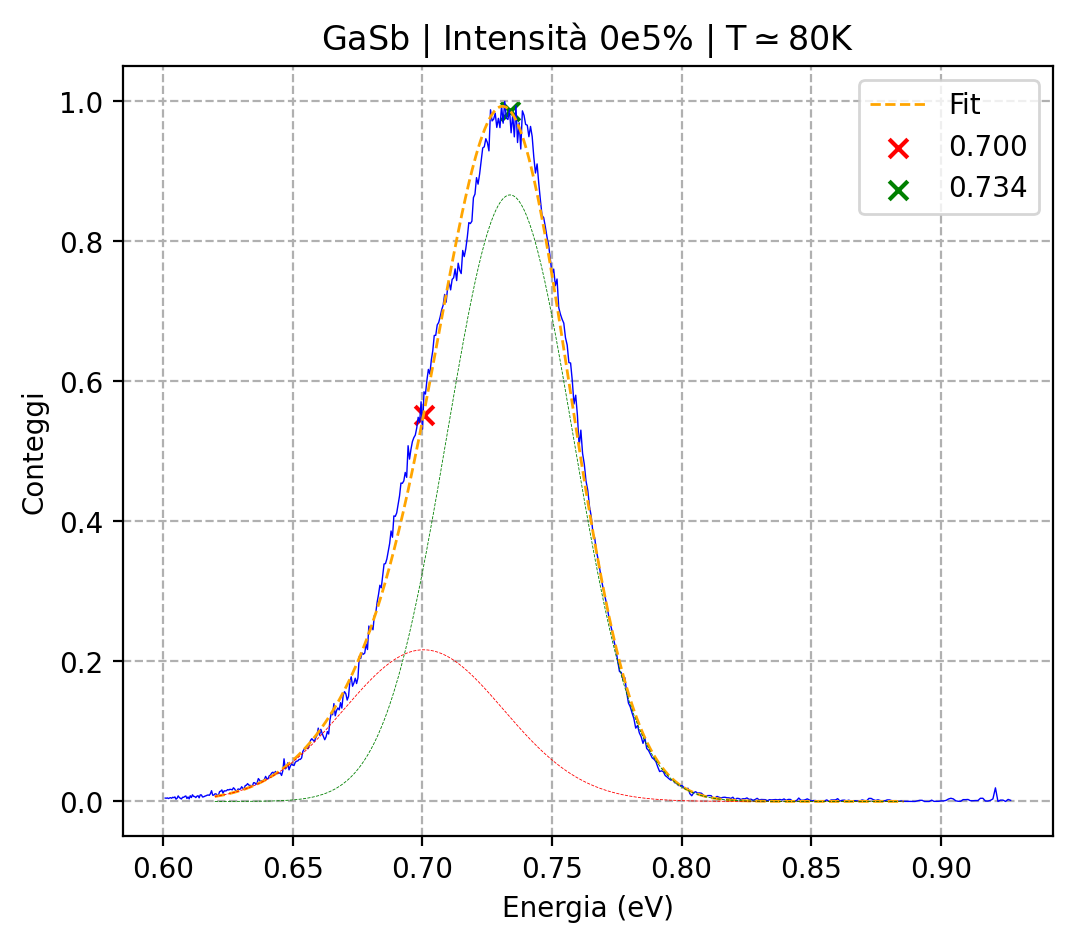

• Gaussiana  1
 - A = 0.8664535812464089
 - mu = 0.7338108818053308
 - sigma = 0.024215173899490034
• Gaussiana  2
 - A = 0.2166478464309308
 - mu = 0.7004811686726549
 - sigma = 0.030759916742652667
 - chi2rid = 16849678.35479582


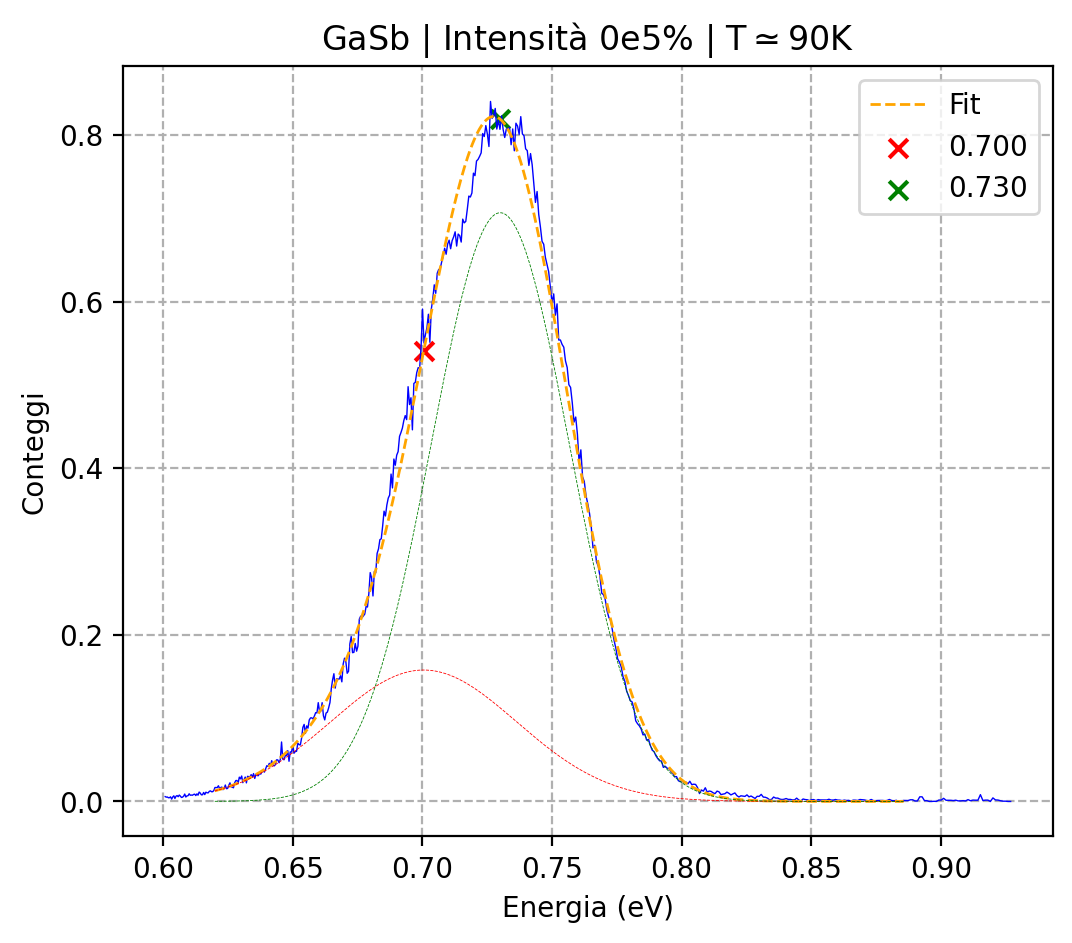

• Gaussiana  1
 - A = 0.7067287365552002
 - mu = 0.7300363443258281
 - sigma = 0.02667586187796536
• Gaussiana  2
 - A = 0.15776833016016964
 - mu = 0.7004811686726552
 - sigma = 0.03584335340361469
 - chi2rid = 15893034.266012684


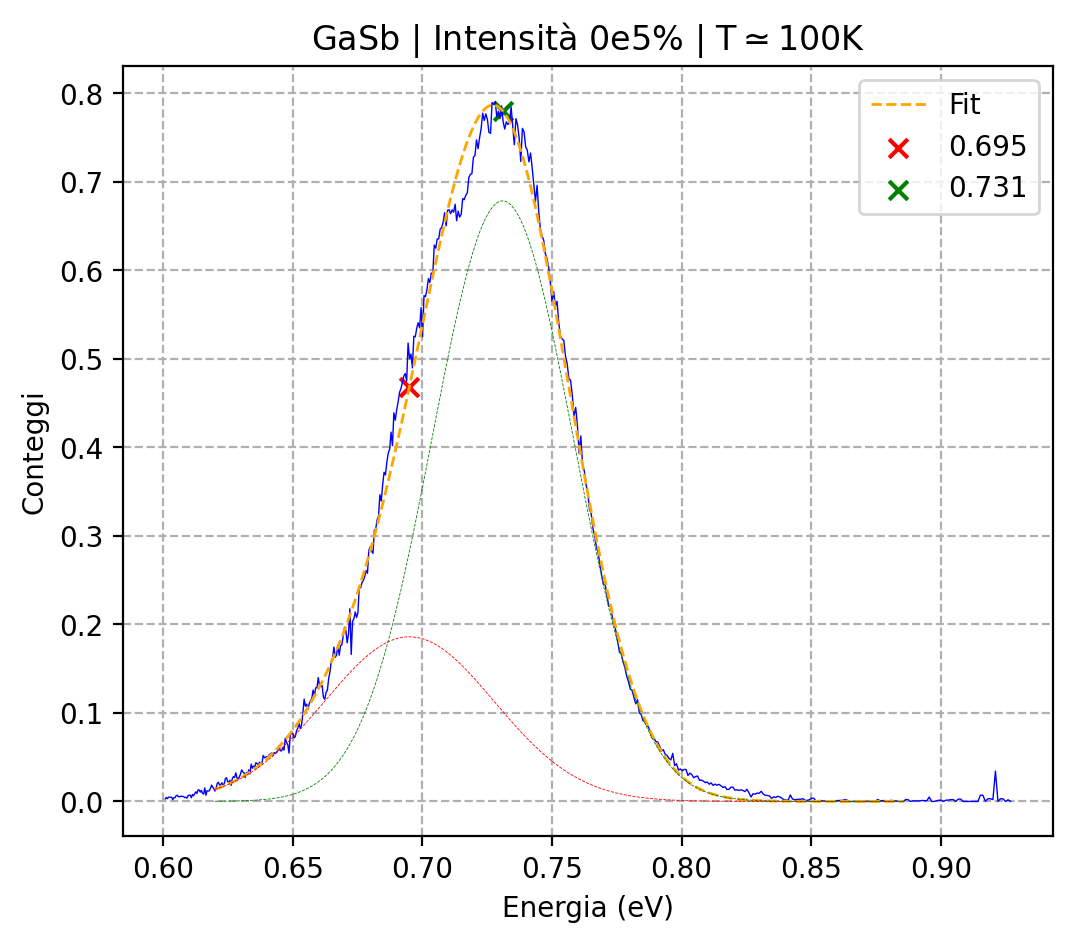

• Gaussiana  1
 - A = 0.67857717012287
 - mu = 0.7309926248917153
 - sigma = 0.027182235415280663
• Gaussiana  2
 - A = 0.18604064631731593
 - mu = 0.694979302195262
 - sigma = 0.03277610894001262
 - chi2rid = 22011778.801152077


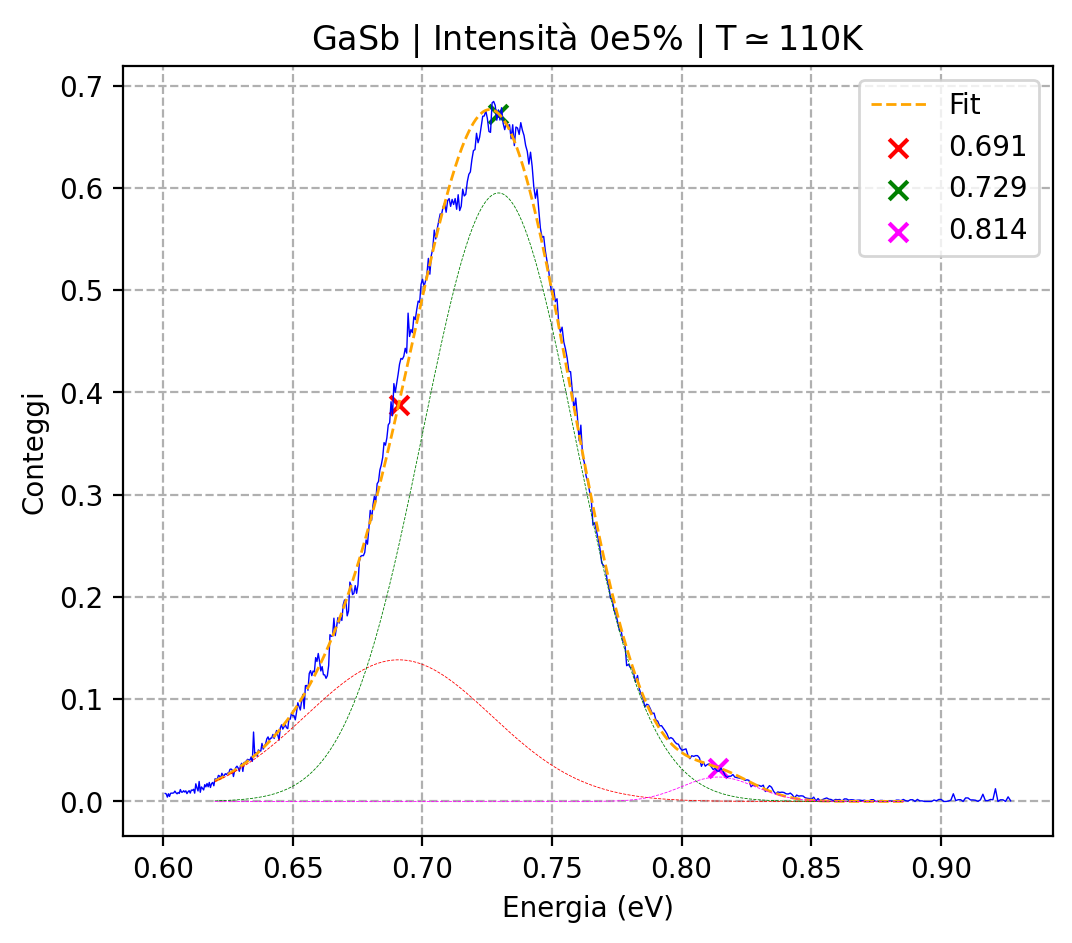

• Gaussiana  1
 - A = 0.02388293648120517
 - mu = 0.8141716046106184
 - sigma = 0.01417178303743357
• Gaussiana  2
 - A = 0.59500920442994
 - mu = 0.7293666556133909
 - sigma = 0.02922000750453828
• Gaussiana  3
 - A = 0.13848504446790008
 - mu = 0.6908464157941597
 - sigma = 0.03578635149454838
 - chi2rid = 9400484.383783184


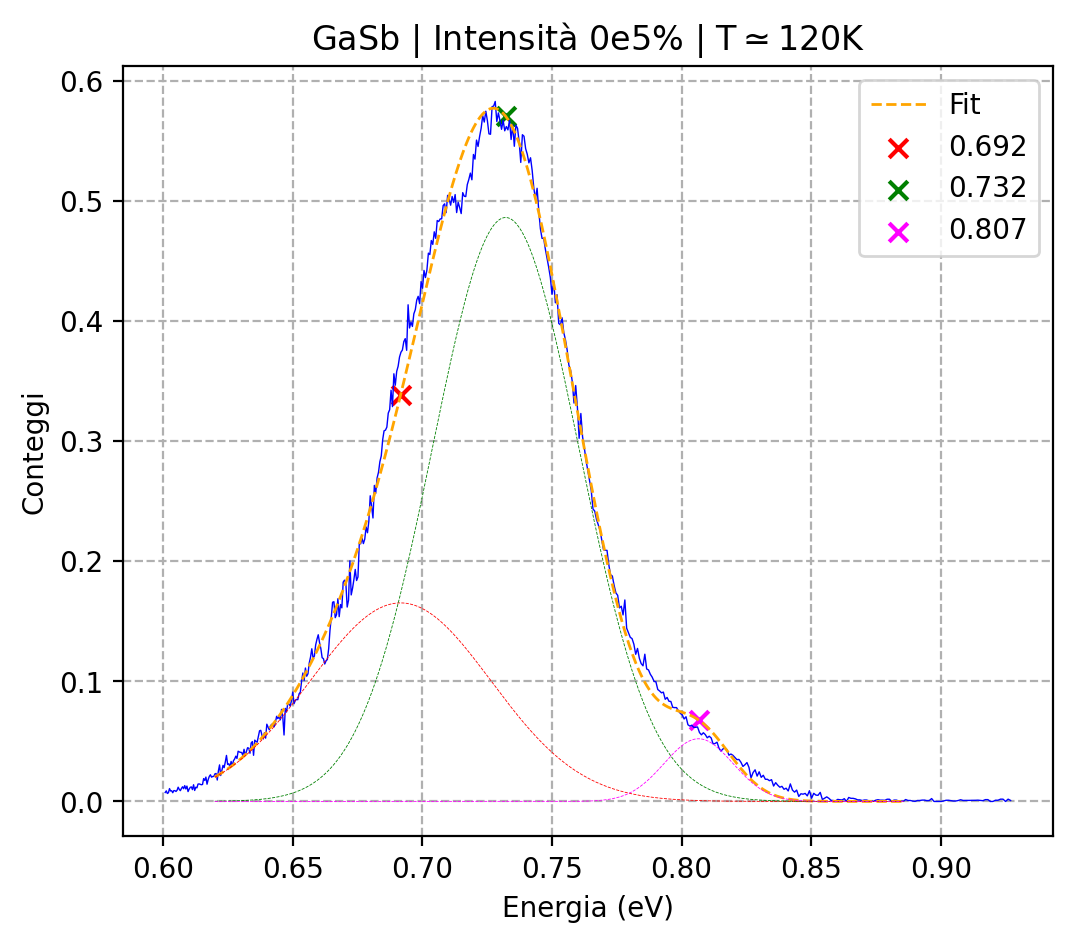

• Gaussiana  1
 - A = 0.05219503366397165
 - mu = 0.8065353306709059
 - sigma = 0.01328565372358499
• Gaussiana  2
 - A = 0.4861823462493533
 - mu = 0.7321245148281725
 - sigma = 0.028199162050487087
• Gaussiana  3
 - A = 0.16531234786678295
 - mu = 0.6915933535562899
 - sigma = 0.03493377895927192
 - chi2rid = 17943922.24541585


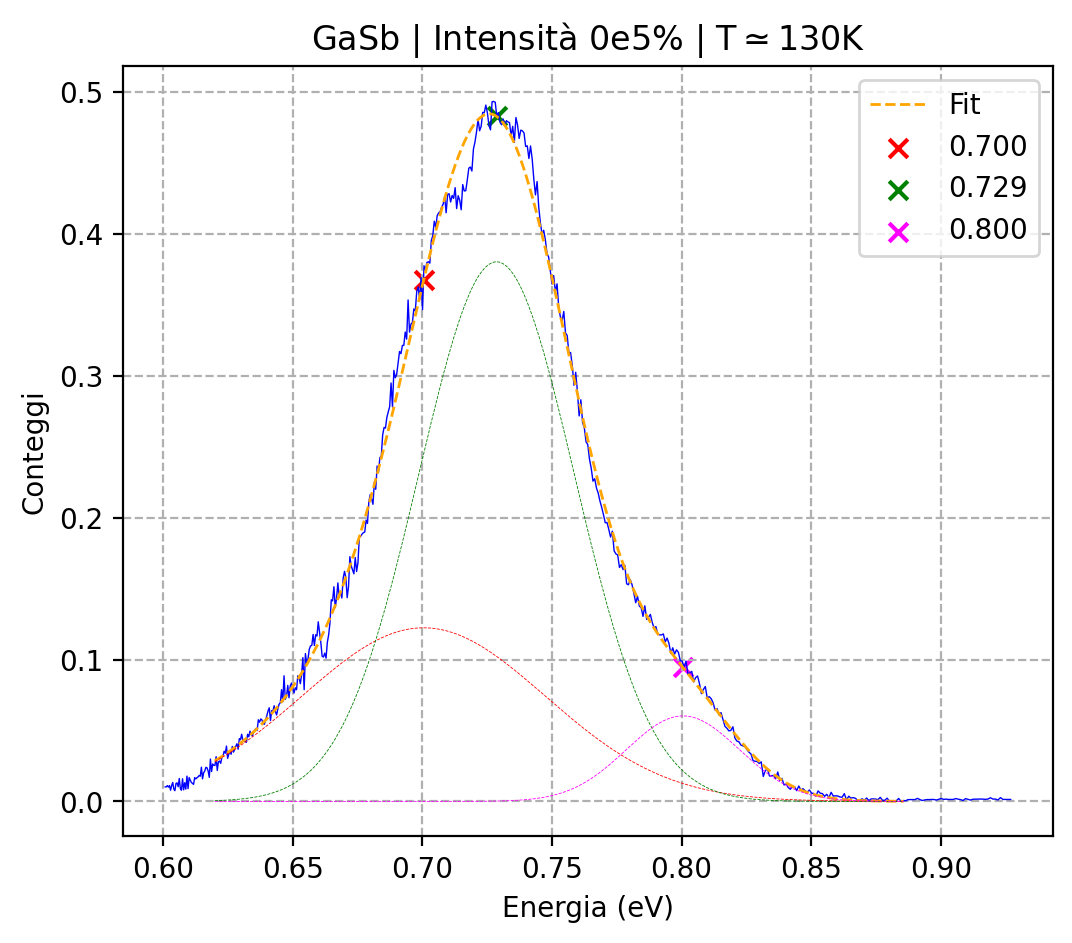

• Gaussiana  1
 - A = 0.06028851847091323
 - mu = 0.8004948061998761
 - sigma = 0.02178593139238312
• Gaussiana  2
 - A = 0.38033995436378376
 - mu = 0.7286205548101565
 - sigma = 0.029987185259276537
• Gaussiana  3
 - A = 0.12239338996384694
 - mu = 0.7004811686726552
 - sigma = 0.04693760673190566
 - chi2rid = 5877081.465221046


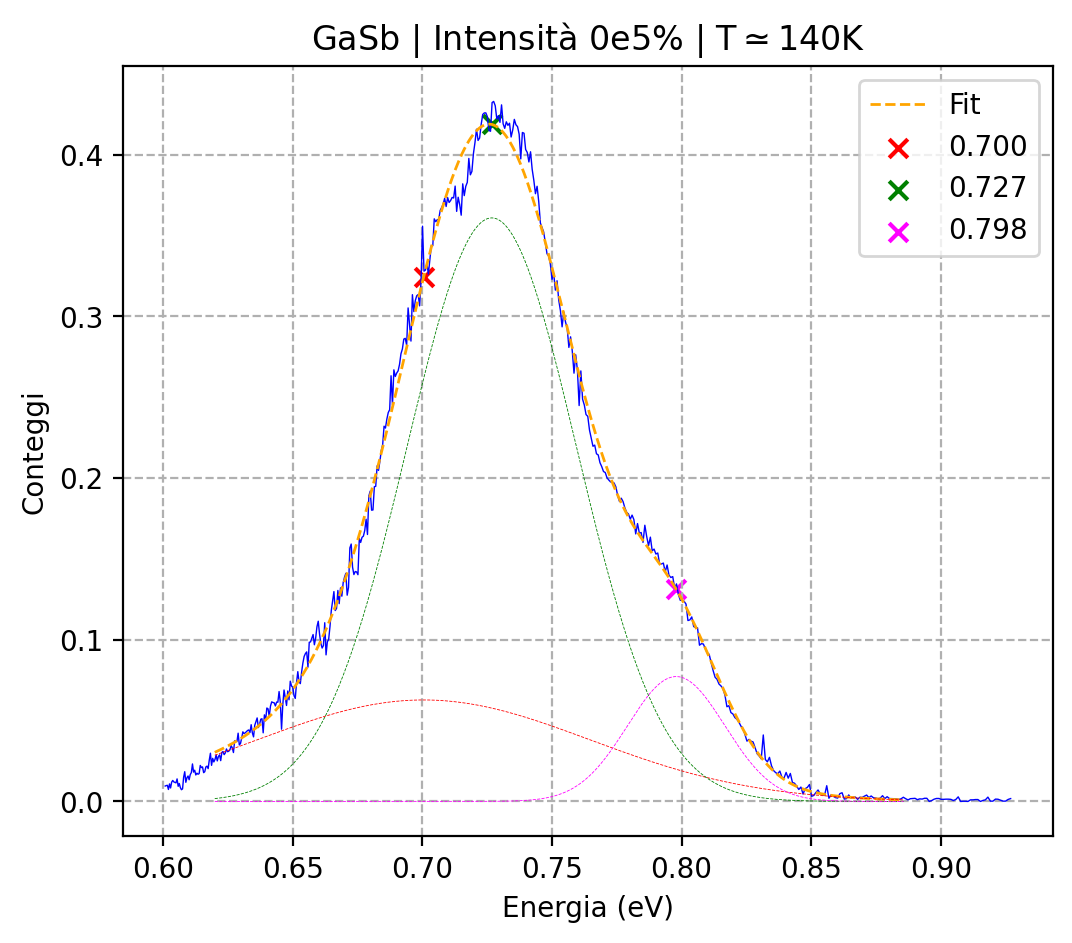

• Gaussiana  1
 - A = 0.077230039393226
 - mu = 0.797901126223474
 - sigma = 0.018784271718803626
• Gaussiana  2
 - A = 0.3608850350892779
 - mu = 0.7267667065818324
 - sigma = 0.03273796729425178
• Gaussiana  3
 - A = 0.06276939944788056
 - mu = 0.7004811686726552
 - sigma = 0.06425653446743172
 - chi2rid = 5499114.20552351


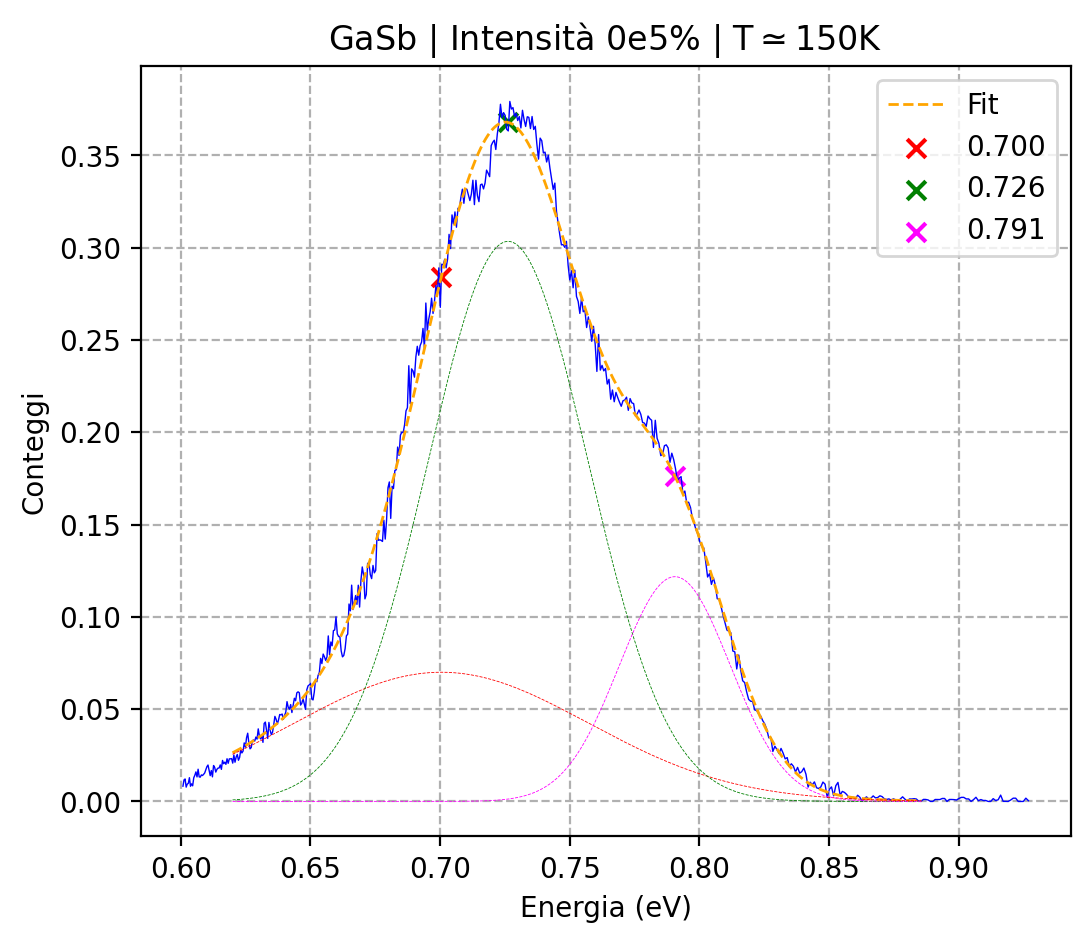

• Gaussiana  1
 - A = 0.12175752881974602
 - mu = 0.7905463839278187
 - sigma = 0.02135072243002333
• Gaussiana  2
 - A = 0.3033873254435815
 - mu = 0.7262316604249572
 - sigma = 0.030877618749323807
• Gaussiana  3
 - A = 0.06999102089217825
 - mu = 0.7004811686726538
 - sigma = 0.0567317549727004
 - chi2rid = 5480969.106407642


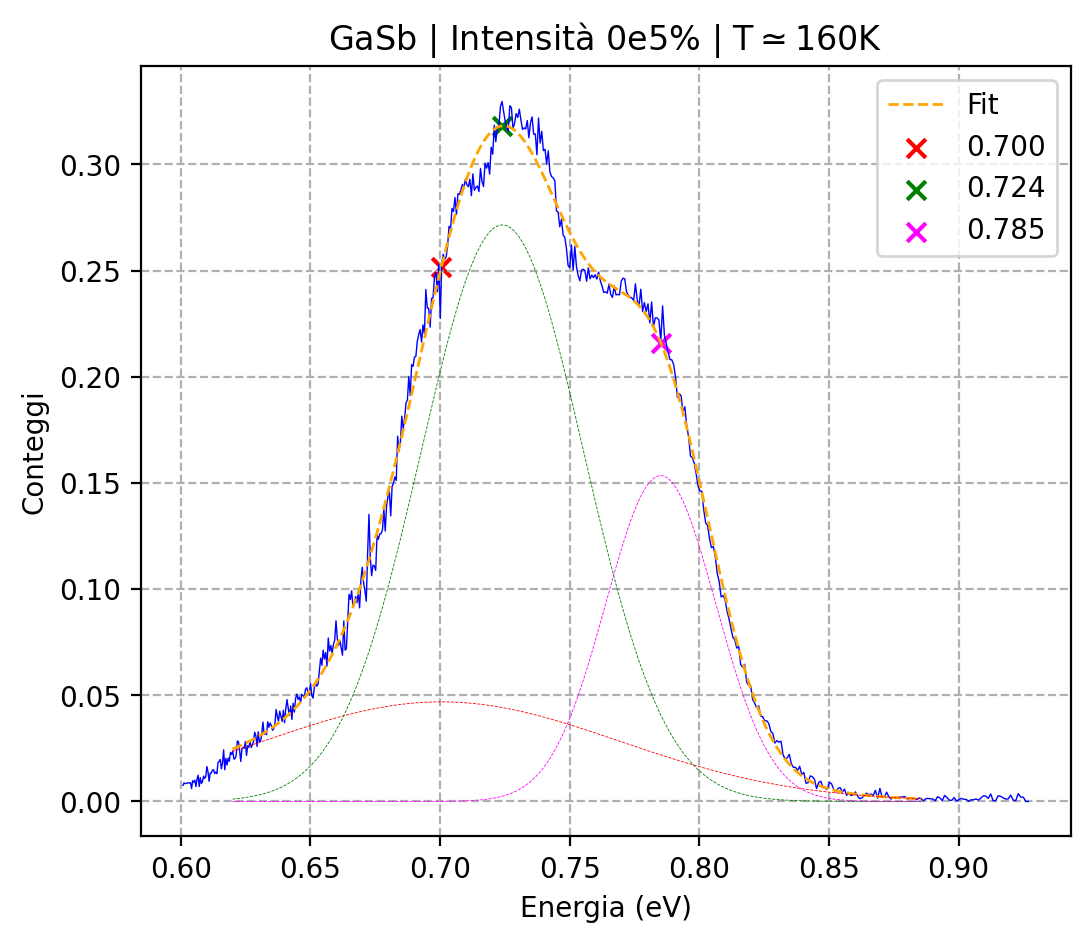

• Gaussiana  1
 - A = 0.15345610941023138
 - mu = 0.7851038050119268
 - sigma = 0.021243712626730707
• Gaussiana  2
 - A = 0.2715167919039167
 - mu = 0.7240293077849345
 - sigma = 0.031359718382215546
• Gaussiana  3
 - A = 0.046908159408634326
 - mu = 0.7004811686725465
 - sigma = 0.0685928861103803
 - chi2rid = 4339399.9906155765


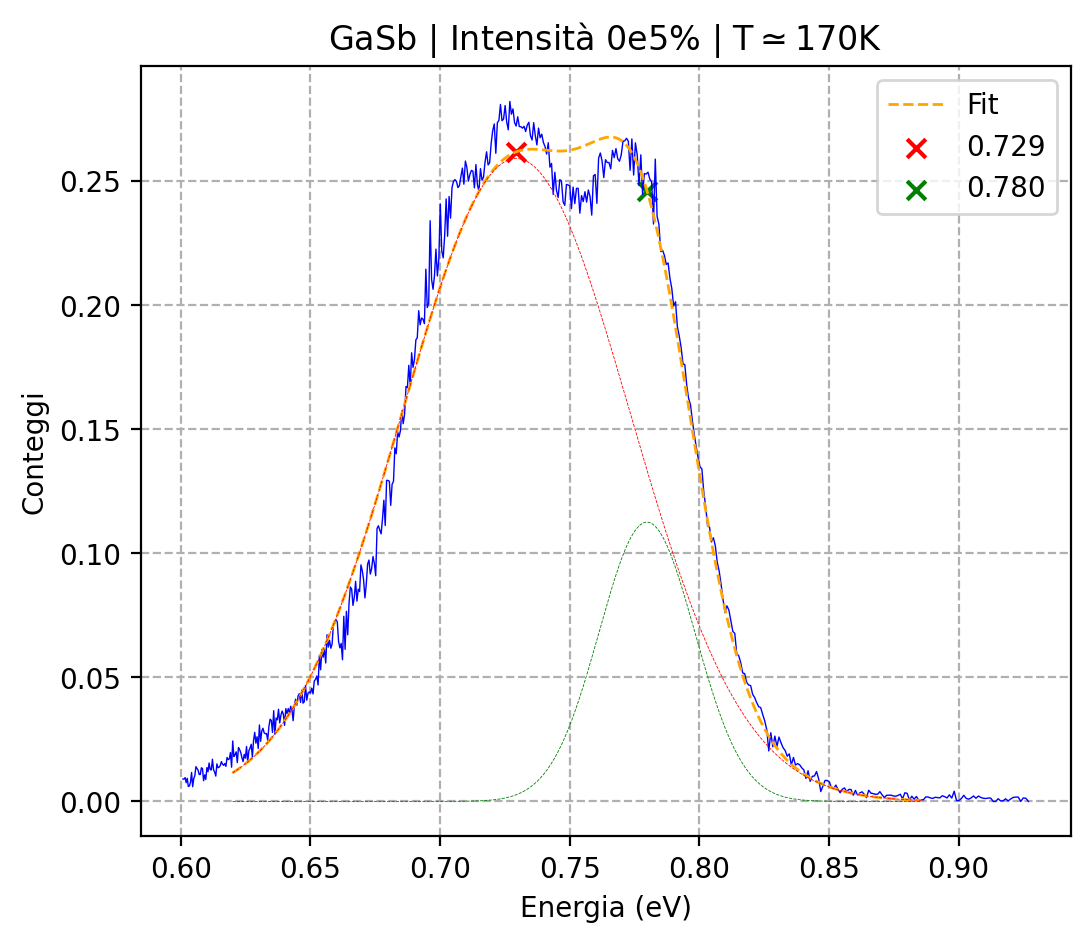

• Gaussiana  1
 - A = 0.11259465046091513
 - mu = 0.7797809236167295
 - sigma = 0.018456523481823868
• Gaussiana  2
 - A = 0.25917403126722427
 - mu = 0.7293245109121175
 - sigma = 0.04383456349068608
 - chi2rid = 11763537.782691598


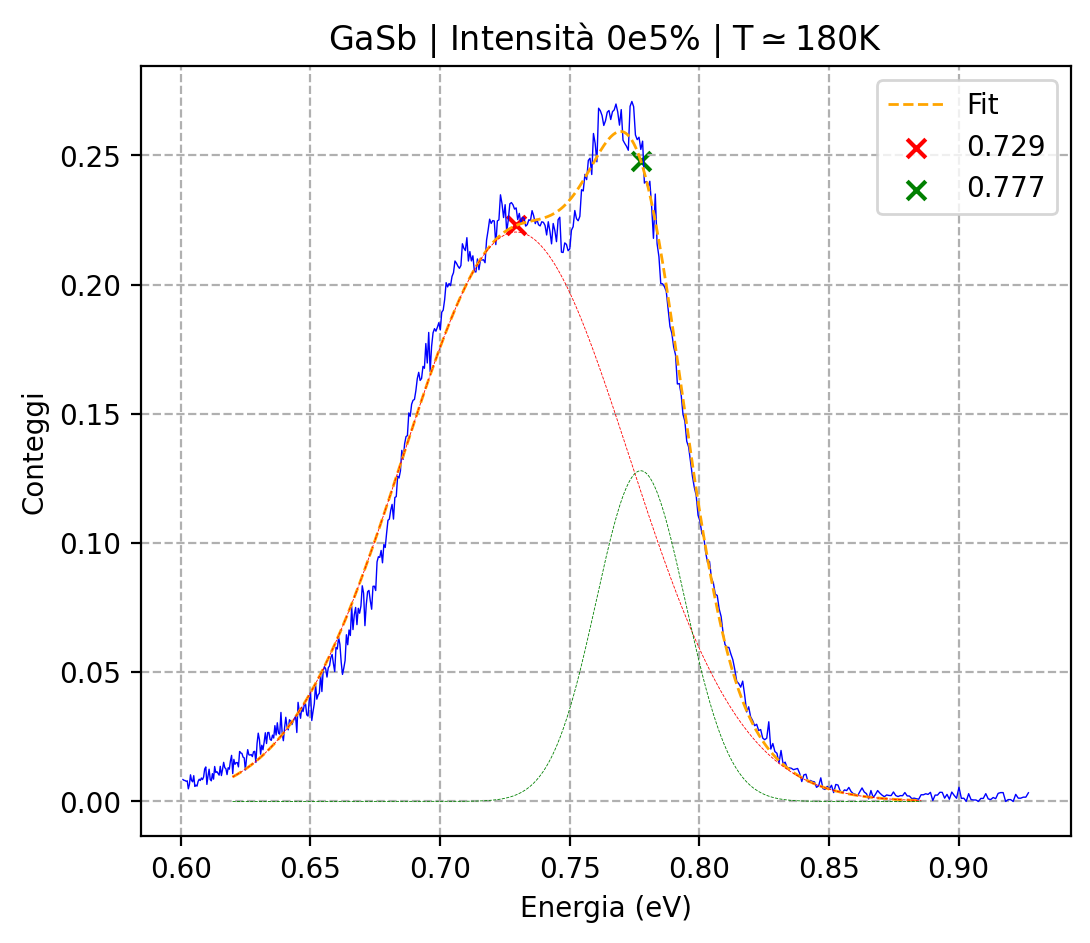

• Gaussiana  1
 - A = 0.12794558086194574
 - mu = 0.7773868324101717
 - sigma = 0.017170545237752355
• Gaussiana  2
 - A = 0.2203064942522651
 - mu = 0.7293245109121175
 - sigma = 0.04359256793256761
 - chi2rid = 8785479.824538734


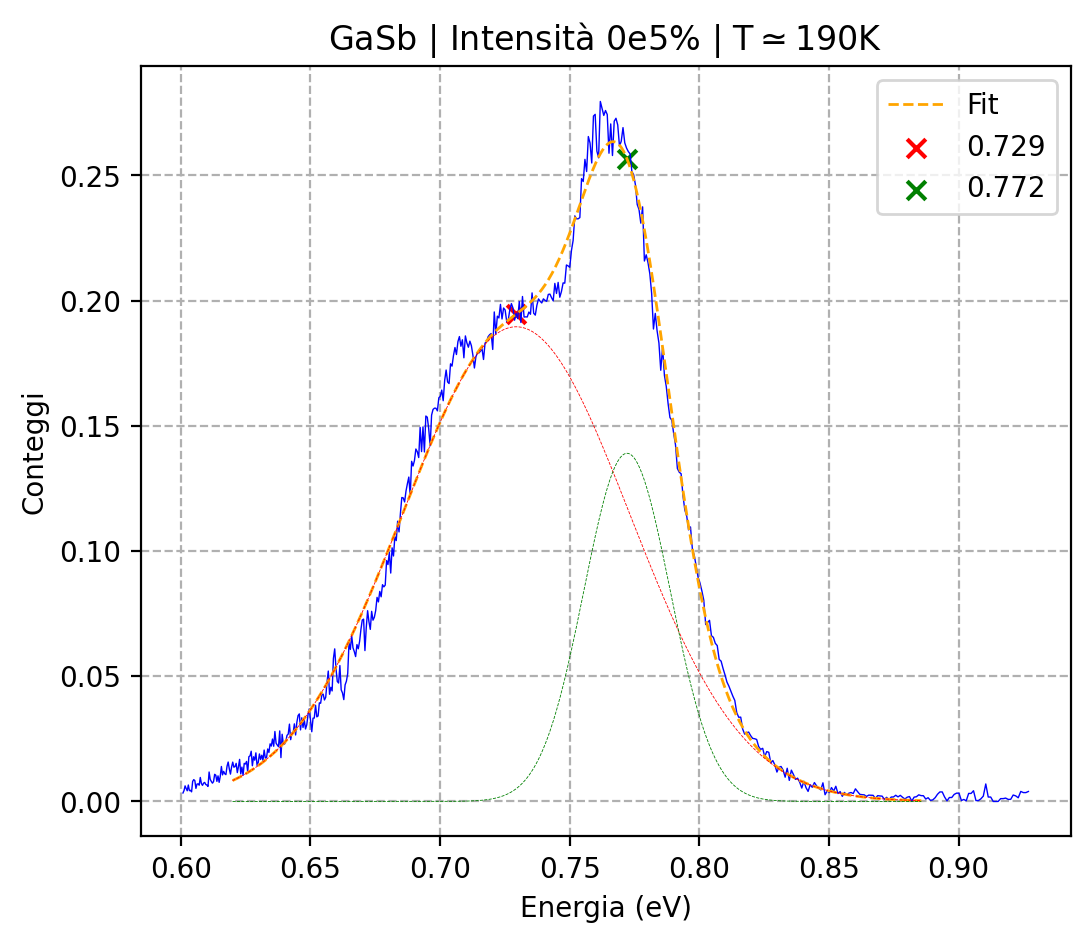

• Gaussiana  1
 - A = 0.13902538617200233
 - mu = 0.772111341190259
 - sigma = 0.016629285457836943
• Gaussiana  2
 - A = 0.18955011867405305
 - mu = 0.7293245109121175
 - sigma = 0.04375821970318424
 - chi2rid = 7539591.059123085


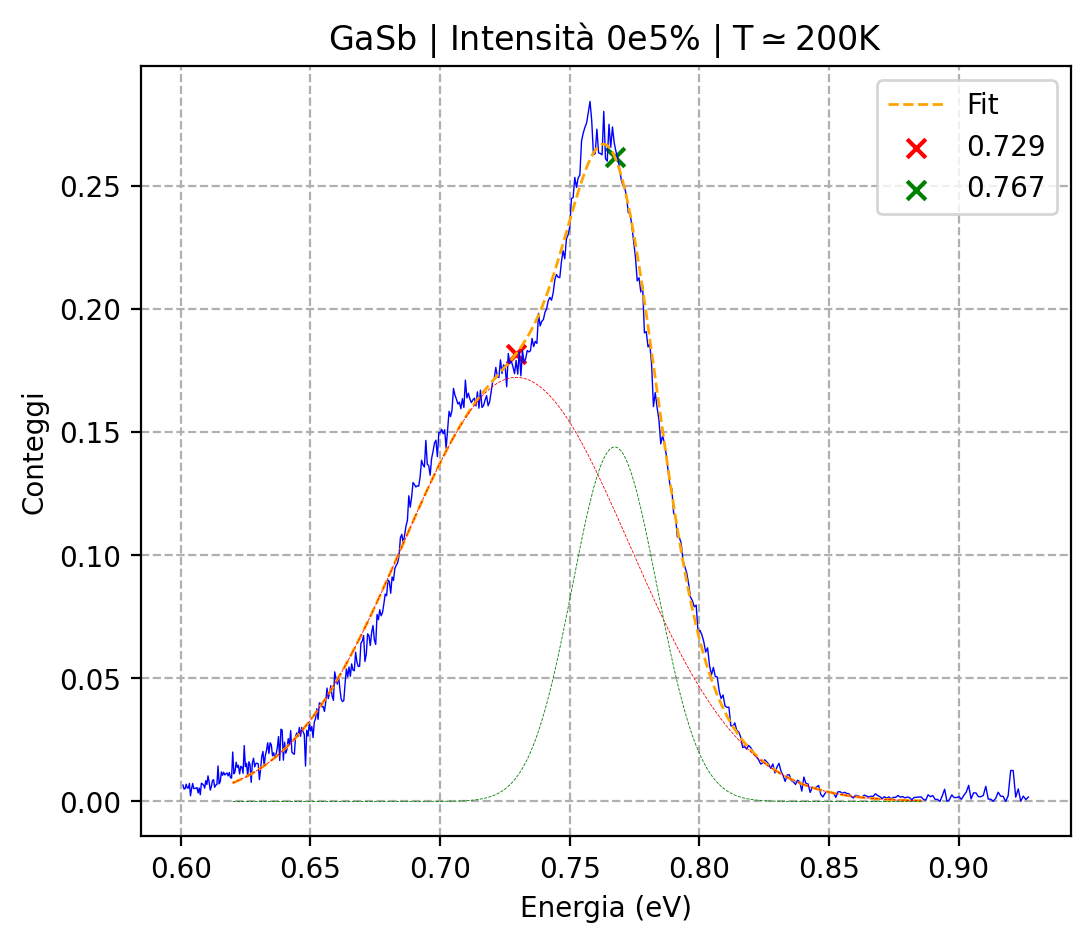

• Gaussiana  1
 - A = 0.1440063151084931
 - mu = 0.7673396714651461
 - sigma = 0.016342257391735244
• Gaussiana  2
 - A = 0.17228423821239827
 - mu = 0.7293245109121175
 - sigma = 0.04367713282668745
 - chi2rid = 7983730.612238159


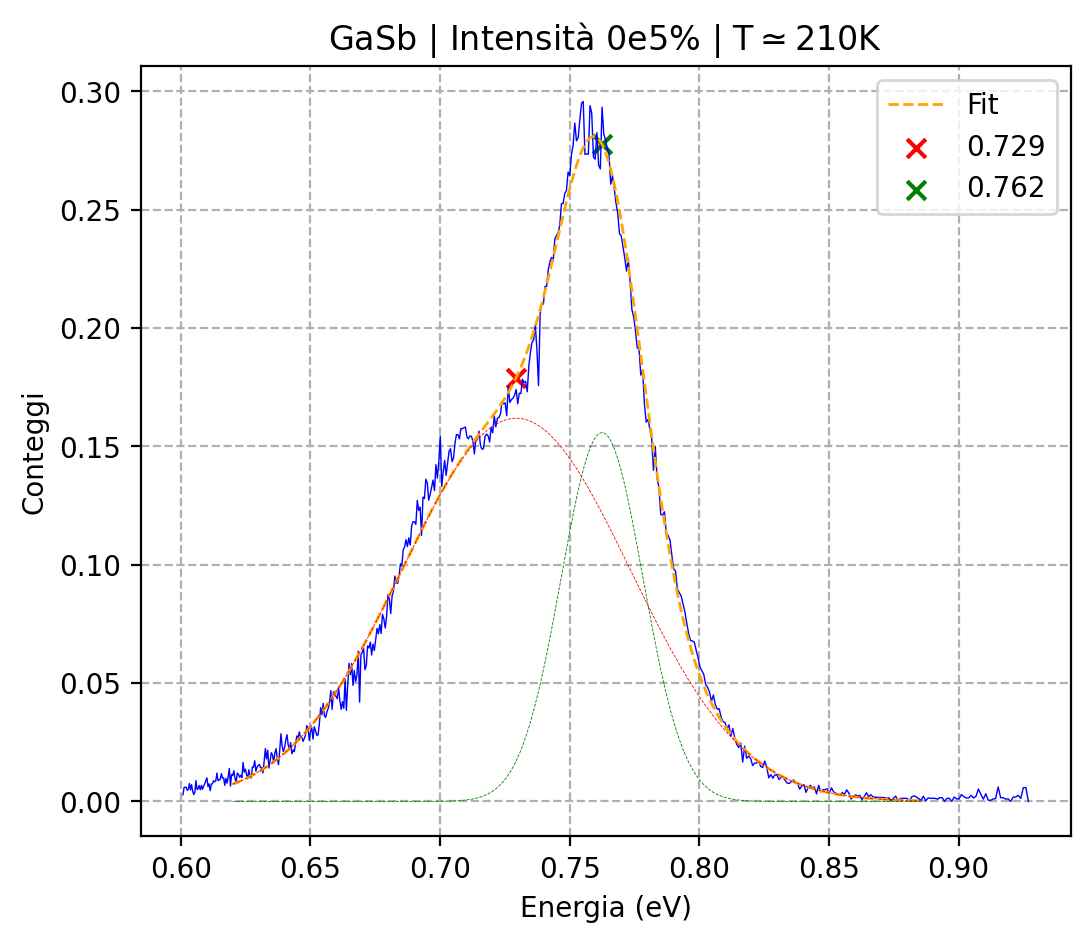

• Gaussiana  1
 - A = 0.15580651320855915
 - mu = 0.762478762824372
 - sigma = 0.015776550838885493
• Gaussiana  2
 - A = 0.16189220659549755
 - mu = 0.7293245109121175
 - sigma = 0.04390405338091665
 - chi2rid = 6492562.941140807


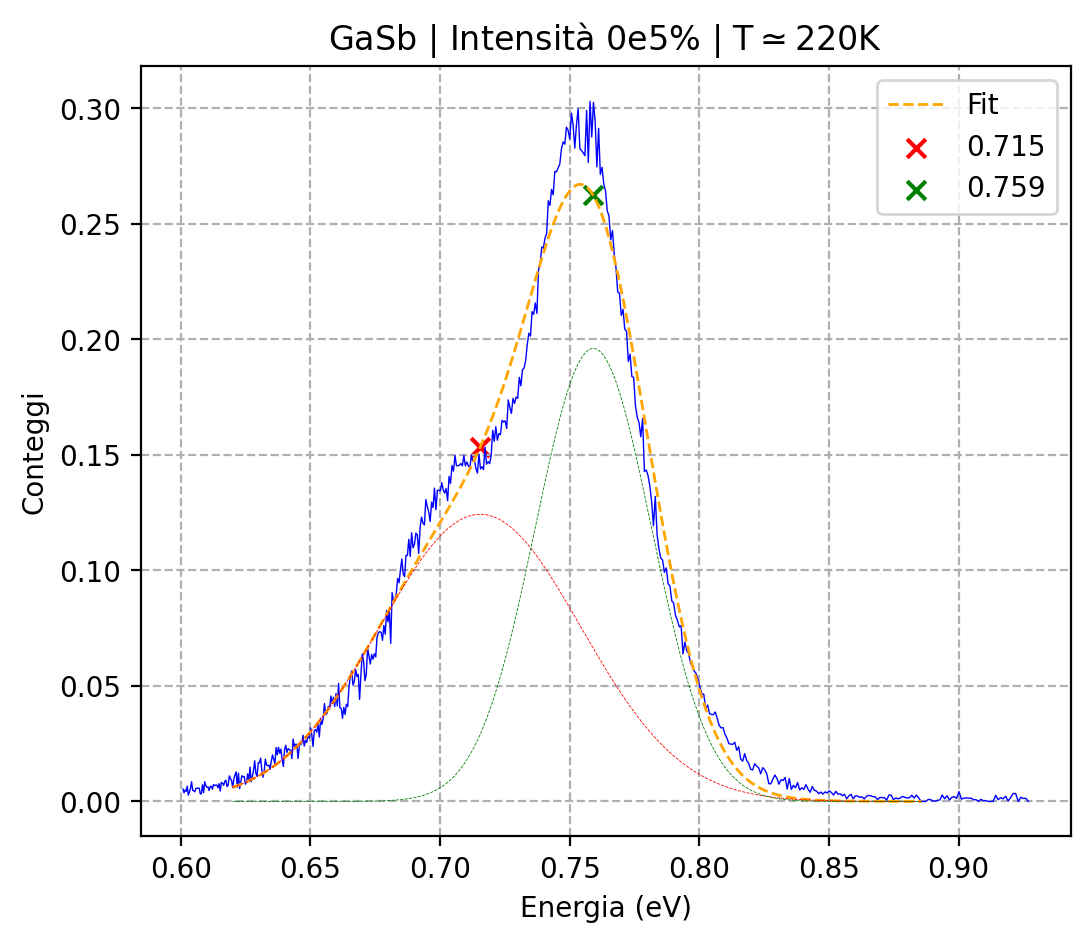

• Gaussiana  1
 - A = 0.19607329315406832
 - mu = 0.7591049673309949
 - sigma = 0.02234190982156979
• Gaussiana  2
 - A = 0.12430239176134905
 - mu = 0.7154739969743938
 - sigma = 0.03888778558809143
 - chi2rid = 19564060.455662582


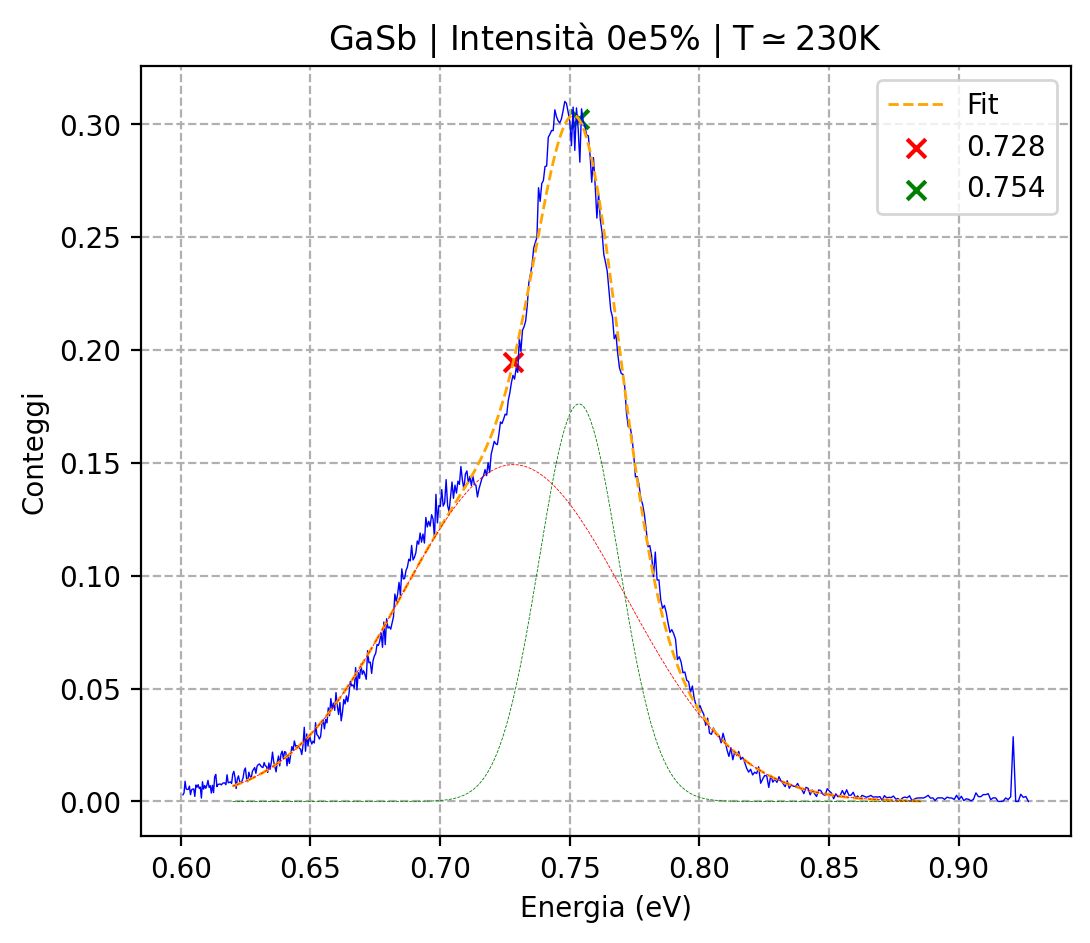

• Gaussiana  1
 - A = 0.17611619423760827
 - mu = 0.7535491821866607
 - sigma = 0.015396151938521532
• Gaussiana  2
 - A = 0.1492287559829521
 - mu = 0.7282557143667076
 - sigma = 0.04354977922503813
 - chi2rid = 6519697.726658862


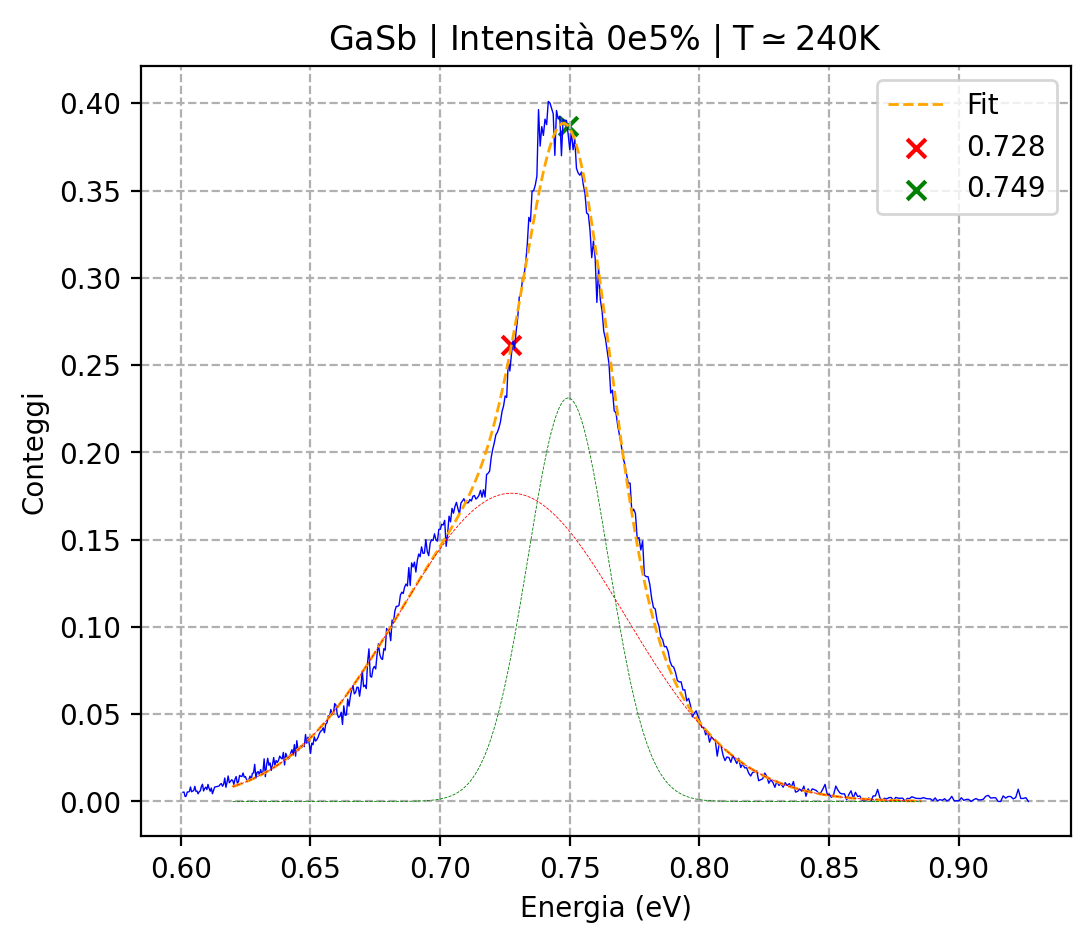

• Gaussiana  1
 - A = 0.23116014556324715
 - mu = 0.7493671874386763
 - sigma = 0.01542436947368763
• Gaussiana  2
 - A = 0.17659864820564855
 - mu = 0.7275125727301816
 - sigma = 0.04363104647565169
 - chi2rid = 8491392.621962102


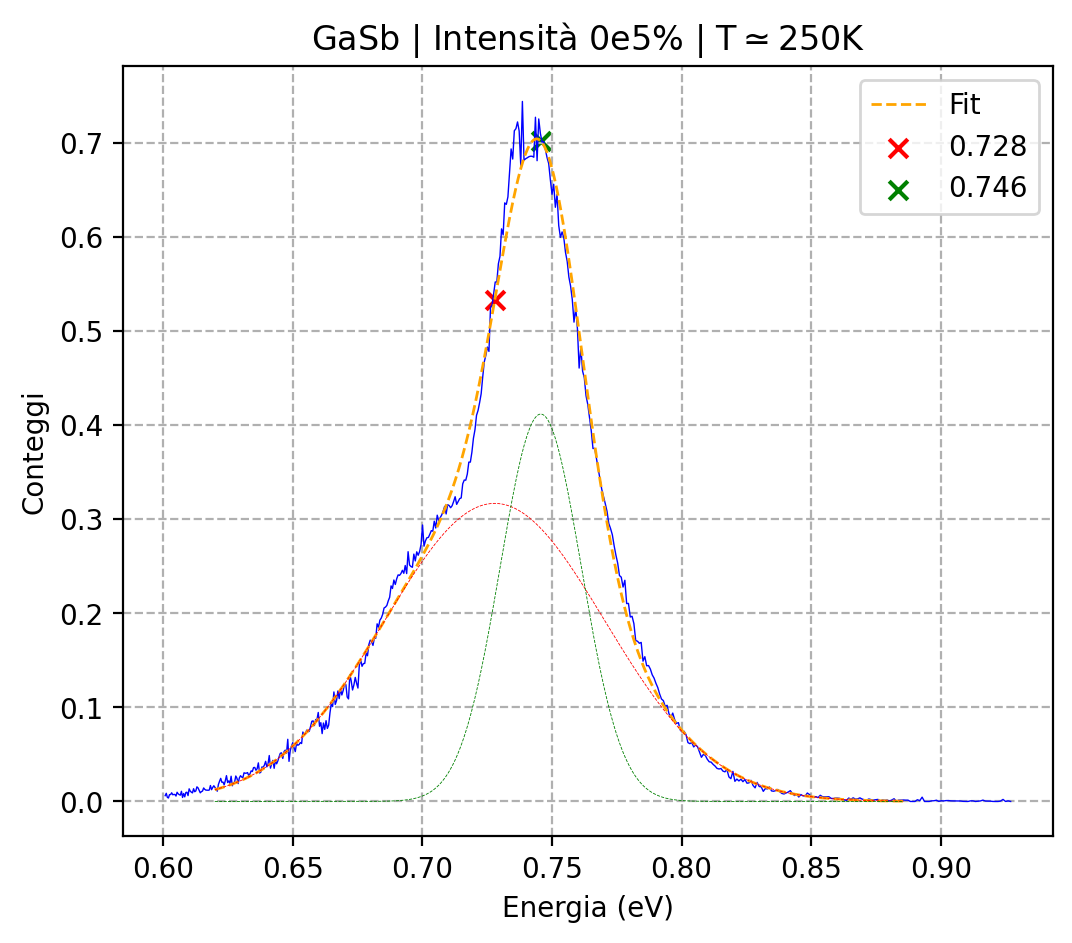

• Gaussiana  1
 - A = 0.4117921100627532
 - mu = 0.7456673275987514
 - sigma = 0.01562476208082547
• Gaussiana  2
 - A = 0.31685790118109775
 - mu = 0.7279000946268755
 - sigma = 0.042457553627582204
 - chi2rid = 11217544.30114733


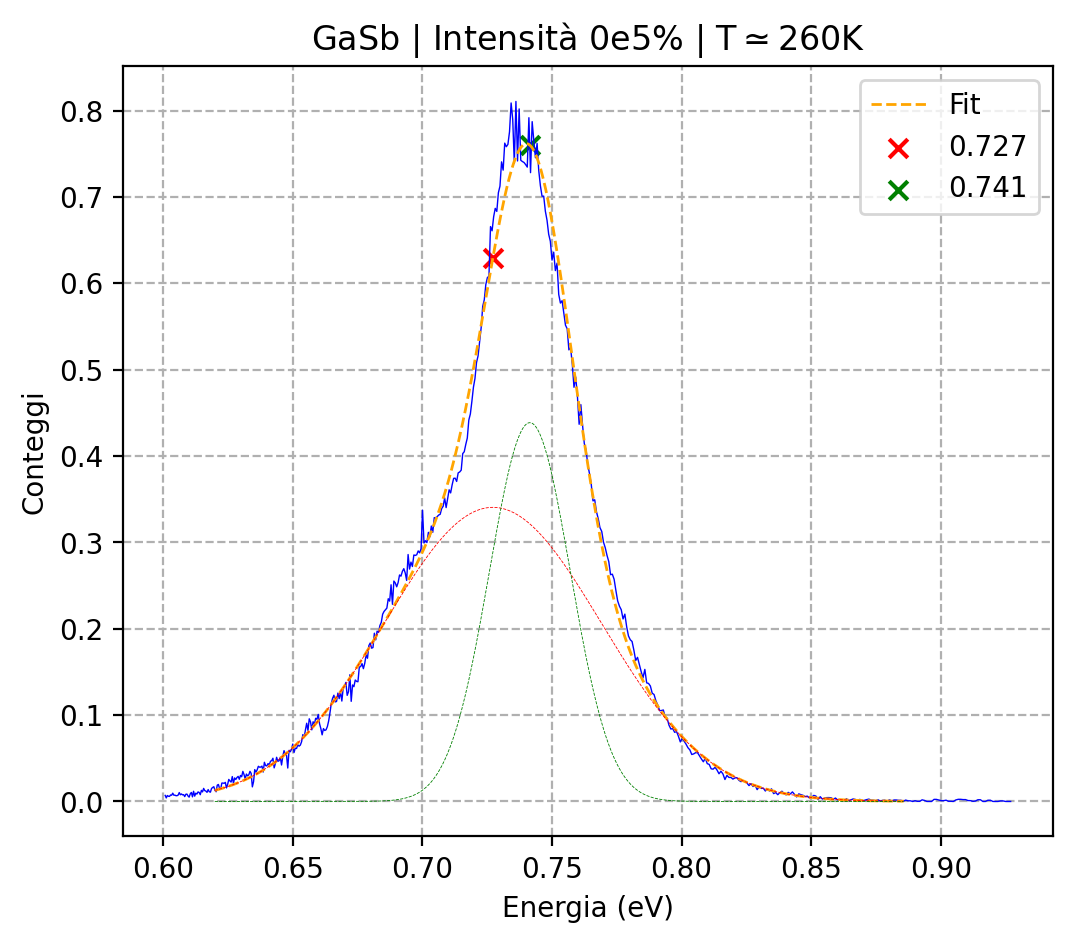

• Gaussiana  1
 - A = 0.4385660053471085
 - mu = 0.741466036488125
 - sigma = 0.015620323450245407
• Gaussiana  2
 - A = 0.34053650260332124
 - mu = 0.7271969311030916
 - sigma = 0.04186254616787995
 - chi2rid = 12082411.357693126


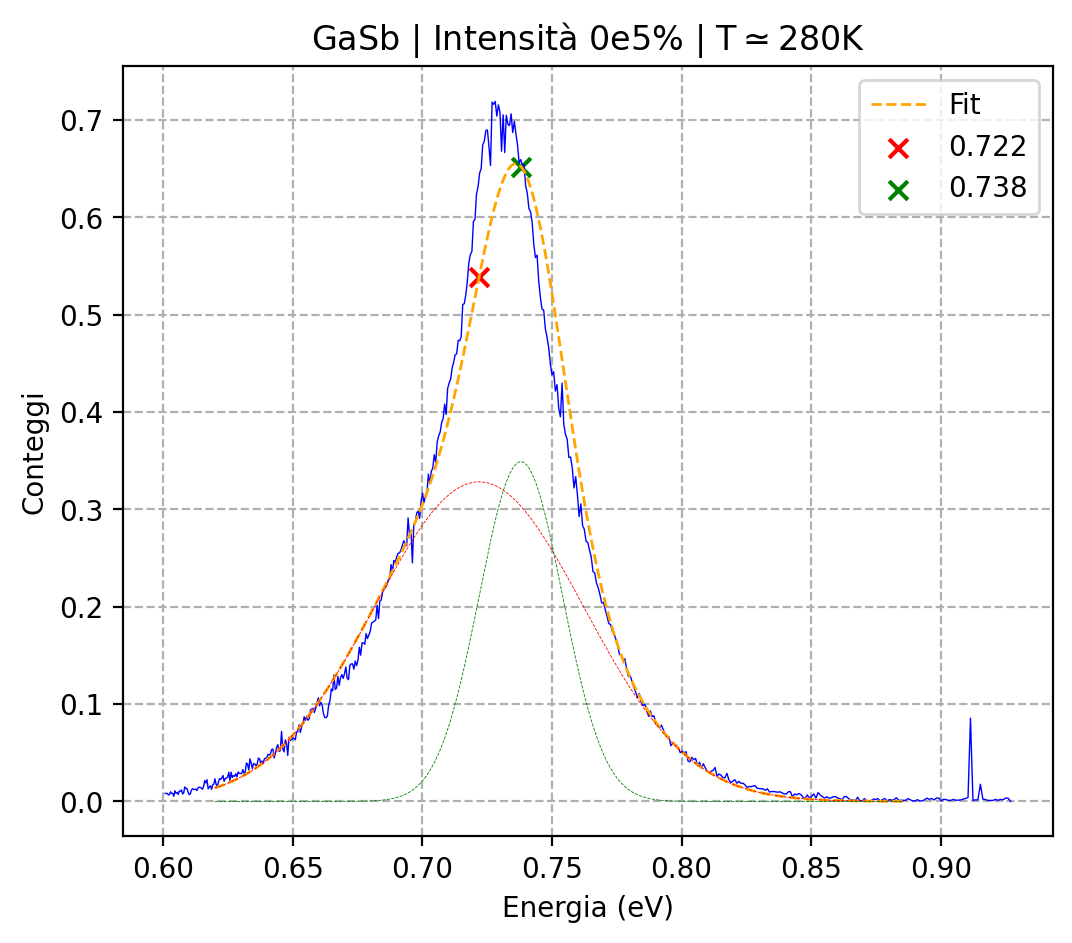

• Gaussiana  1
 - A = 0.3489990549221923
 - mu = 0.7380069455658335
 - sigma = 0.016043961409199437
• Gaussiana  2
 - A = 0.3283600575313507
 - mu = 0.7218700023940875
 - sigma = 0.04050632458493322
 - chi2rid = 29394676.552619807


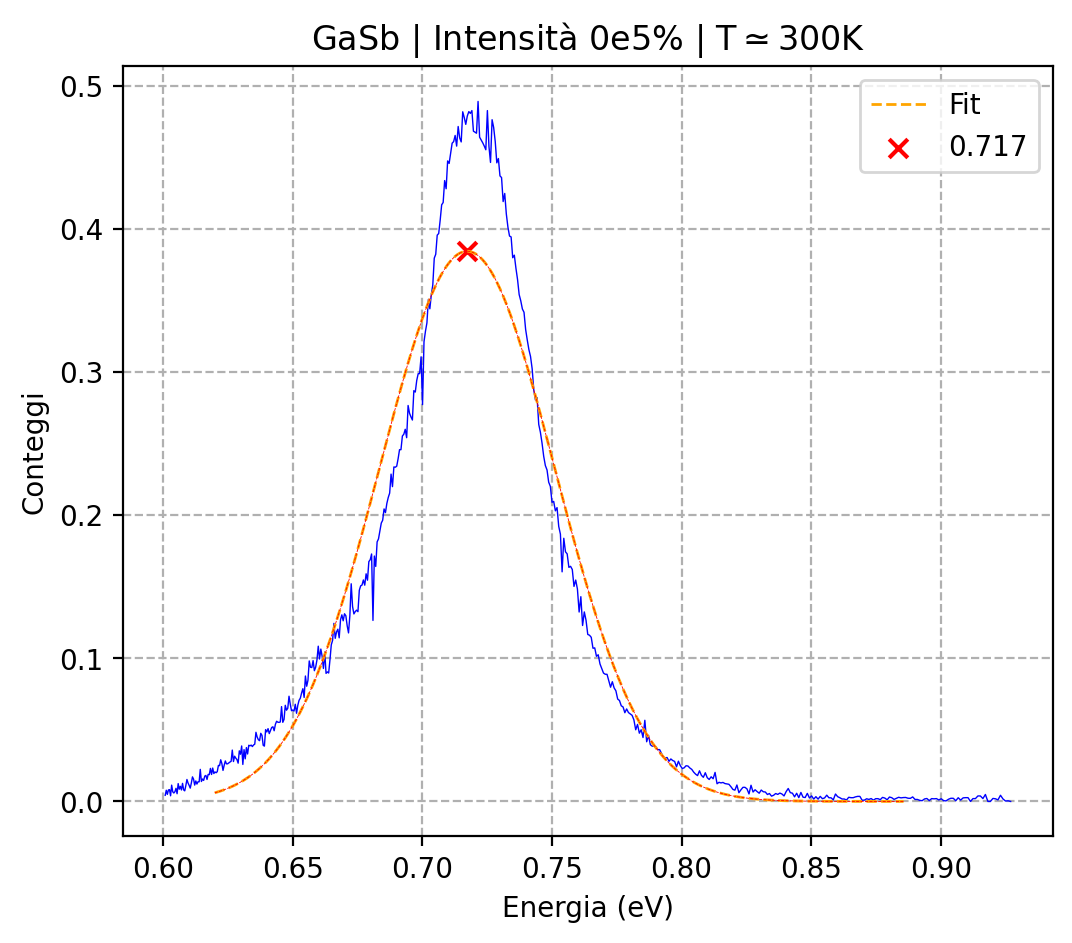

• Gaussiana  1
 - A = 0.38445834790839034
 - mu = 0.7172517359951801
 - sigma = 0.03376003325904265
 - chi2rid = 75780311.69814096


In [239]:
# imposto parametri INIZIALI: ogni entrata è una tripla (a, mu, sigma)
params = [
    (1, 1650, 50)
]
# successivamente, ad ogni iterazione i parametri usati sono quelli del fit precedente

for T in arr_T:
    
    waveln = GaSb_T[T][0]
    counts = GaSb_T[T][1]
    
    if T == '78e68':
        T = '80'
    
    ## normalizzo i counts ##
    # creo vettore degli errori sui counts normalizzati (propagando errore)
    counts_sicuro = np.where(counts == 0, 1, counts)  
    err_counts = (np.sqrt(counts_sicuro)/conteggio_massimo_assoluto) / (np.sqrt(40*n_acq)) 
    # sul massimo count del plot attualmente considerato
    '''maximum = np.max(counts)
    counts = counts / maximum'''
    # sul massimo count di tutti i plot
    counts = counts / conteggio_massimo_assoluto 
    
    # converto in eV
    energy = lambda_to_E (waveln)
    
    # Plot
    plt.figure(figsize=(6,5), dpi=200)
    plt.plot(energy, counts, linestyle='-', color='b', linewidth=0.5)#, zorder=1)
    
    ## FIT ##
    
    # isolo regione 1400 < x < 2000
    mask = (waveln > 1400) & (waveln < 2000)
    x_fit = energy[mask]
    y_fit = counts[mask]
    err_counts = err_counts[mask]
    
    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
    # HACK: MAGHEGGINI 
    ## prendo il massimo dei counts normalizzati per impostare i bounds di A ##
    massimo_locale = np.max(counts)
    low_A = massimo_locale/50
    upp_A = massimo_locale
    
    if 80 <= int(T) <= 100:
        N_MAX_GAUSS = 2
        params = [
            (low_A, lambda_to_E(1670), 0.05),
            (low_A, lambda_to_E(1800), 0.05)
        ]
        low = [low_A, lambda_to_E(1730), 0.001,  low_A, lambda_to_E(1830), 0.001] 
        upp = [upp_A, lambda_to_E(1620),     1,  upp_A, lambda_to_E(1770),     1] 
    elif 110 <= int(T) <= 160:
        N_MAX_GAUSS = 3
        params = [
            (low_A, lambda_to_E(1540), 0.05),
            (low_A, lambda_to_E(1700), 0.05),
            (low_A, lambda_to_E(1800), 0.05)
        ]
        low = [low_A, lambda_to_E(1620), 0.001,  low_A, lambda_to_E(1730), 0.001,  low_A, lambda_to_E(1830), 0.001] 
        upp = [upp_A, lambda_to_E(1500),     1,  upp_A, lambda_to_E(1670),     1,  upp_A, lambda_to_E(1770), 1] 
    elif 170 <= int(T) < 300:
        N_MAX_GAUSS = 2
        params = [
            (low_A, lambda_to_E(1620), 0.05),
            (low_A, lambda_to_E(1730), 0.05)
        ]
        low = [low_A, lambda_to_E(1680), 0.001,  low_A, lambda_to_E(1760), 0.001] 
        upp = [upp_A, lambda_to_E(1590),     1,  upp_A, lambda_to_E(1700),     1] 
    else: # T == 300
        N_MAX_GAUSS = 1
        params = [
            (low_A, lambda_to_E(1650), 0.05),
        ]
        low = [low_A, lambda_to_E(1760), 0.001] 
        upp = [upp_A, lambda_to_E(1590),     1] 
    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
    
    popt, pcov, chi2_reduced = fit_N_gaussiane(x_fit, y_fit, params, 
                                               bounds=(low,upp), 
                                               N_MAX_GAUSS=N_MAX_GAUSS,
                                               n_acq=n_acq,
                                               err_counts=err_counts,
                                               PREVENT_OVERFIT=False)
    
    
    ## PLOT CURVA FIT ##
    x_plot = np.linspace(lambda_to_E(2000), lambda_to_E(1400), 600)
    y_plot = N_gaussiane(x_plot, *popt)
    plt.plot(x_plot, y_plot, linestyle='--', color='orange', label=f"Fit", linewidth=1)#, zorder=2)
    
    # estraggo da popt i parametri ottimizzati
    valori = [] # inizializzo
    for i in range(0, round(len(popt)/3)):
        valori.append((popt[3*i], popt[3*i+1], popt[3*i+2]))
    # li imposto per la prossima gaussiana
    params = valori
    
    # organizzo i picchi in ordine crescente
    valori = sorted(valori, key=lambda p: float(p[1]))
    n_picchi = len(valori)
    
    # plotto i picchi individuati dal fit
    for i in range(n_picchi): 
        x_picco = valori[i][1]    
        y_picco = N_gaussiane(x_picco, *popt)
        plt.scatter(x_picco, y_picco, 
                    color=col[i], marker='x',
                    label=(f'{x_picco:.3f}'), # stampa nel plot le lambda dei picchi
                    s=45, #alpha=0-1 per opacità
                    #zorder=3
                    )
    
    # plotto singolarmente le gaussiane
    for i in range(n_picchi):
        y_gauss = gaussiana(x_plot, *valori[i])
        plt.plot(x_plot, y_gauss, linestyle='--', color=col[i], linewidth=0.3, zorder=2)
    
    ## OPZIONI GRAFICHE ##
    plt.title(r'GaSb | Intensità 0e5% | T$\simeq$' + T + r'K')
    plt.xlabel("Energia (eV)")
    plt.ylabel("Conteggi")
    #plt.ticklabel_format(axis='y',style='scientific', useMathText=True, scilimits=(0,0) )
    plt.legend()
    plt.grid(linestyle='--')
    #plt.tight_layout()
    plt.show()
    
    ## PRINT RISULTATI FIT ##
    for i in range(0, round(len(popt)/3)):
        print('• Gaussiana ', i+1)
        print(' - A =', popt[3*i])
        print(' - mu =', popt[3*i+1])
        print(' - sigma =', popt[3*i+2])
    print(' - chi2rid =', chi2_reduced)
        
    
    # Raccolgo i picchi in PbS_T_peaks
    GaSb_T_peaks[T] = [] # list di triple (A, mu, sigma)
    for i in range(n_picchi):
        GaSb_T_peaks[T].append(valori[i])

---

In [240]:
GaSb_T_peaks 

{'80': [(np.float64(0.2166478464309308),
   np.float64(0.7004811686726549),
   np.float64(0.030759916742652667)),
  (np.float64(0.8664535812464089),
   np.float64(0.7338108818053308),
   np.float64(0.024215173899490034))],
 '90': [(np.float64(0.15776833016016964),
   np.float64(0.7004811686726552),
   np.float64(0.03584335340361469)),
  (np.float64(0.7067287365552002),
   np.float64(0.7300363443258281),
   np.float64(0.02667586187796536))],
 '100': [(np.float64(0.18604064631731593),
   np.float64(0.694979302195262),
   np.float64(0.03277610894001262)),
  (np.float64(0.67857717012287),
   np.float64(0.7309926248917153),
   np.float64(0.027182235415280663))],
 '110': [(np.float64(0.13848504446790008),
   np.float64(0.6908464157941597),
   np.float64(0.03578635149454838)),
  (np.float64(0.59500920442994),
   np.float64(0.7293666556133909),
   np.float64(0.02922000750453828)),
  (np.float64(0.02388293648120517),
   np.float64(0.8141716046106184),
   np.float64(0.01417178303743357))],
 '120

---